# Medical Image Fusion
A project to fuse a pair of medical images (CT-MRI, PET-MRI, SPECT-MRI) into a single image for better interpretation.

### Model Definition
Using a 4-stage model to extract features, learn, and reconstruct images.

### Model Structure
* Muili-Stream Encoder: Used two separate pre-trained CNNs for extracting feature maps at various resolutions.
* Feature Fusion: Combines the feature maps extracted by encoders.
* Custom UNet Decoder: Upscales and reconstructs the image by using the feature maps.
* Image Refiner (Optional): Refines the final image based of redundant feature maps.

## Environment Initalization

In [1]:
import os
import cv2
import gc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf

# GPU Setup & Memory Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"TensorFlow is using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("TensorFlow is using CPU")

TensorFlow is using GPU: /physical_device:GPU:0


## Dataset Preprocessing

In [2]:
# CT-MRI
dir_1 = '/kaggle/input/datasets/mdrafsanyeasir/thesis45-medical-image/Havard-Medical-Image-Fusion-Datasets-main/CT-MRI/CT'
dir_2 = '/kaggle/input/datasets/mdrafsanyeasir/thesis45-medical-image/Havard-Medical-Image-Fusion-Datasets-main/CT-MRI/MRI'


# PET-MRI
# dir_1 = '/kaggle/input/datasets/mdrafsanyeasir/thesis45-medical-image/Havard-Medical-Image-Fusion-Datasets-main/PET-MRI/MRI'
# dir_2 = '/kaggle/input/datasets/mdrafsanyeasir/thesis45-medical-image/Havard-Medical-Image-Fusion-Datasets-main/PET-MRI/PET'


# SPECT-MRI
# dir_1 = '/kaggle/input/datasets/mdrafsanyeasir/thesis45-medical-image/Havard-Medical-Image-Fusion-Datasets-main/SPECT-MRI/MRI'
# dir_2 = '/kaggle/input/datasets/mdrafsanyeasir/thesis45-medical-image/Havard-Medical-Image-Fusion-Datasets-main/SPECT-MRI/SPECT'

### Muti-Stream Data Loading

In [3]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_and_process_fusion_data_v1(dir_1, dir_2, target_size=(256, 256)):
    """
    Dual-Stream loader for Double Grayscale medical image fusion.
    Returns X1 (3-Ch), X2 (3-Ch), and y (Fused Target 3-Ch).
    """
    filenames = sorted(os.listdir(dir_1))
    num_samples = len(filenames)
    
    # 1. PRE-ALLOCATE MEMORY
    # All arrays must be 3-channel to satisfy the pre-trained ImageNet encoders
    X1 = np.empty((num_samples, target_size[0], target_size[1], 3), dtype=np.float32) 
    X2 = np.empty((num_samples, target_size[0], target_size[1], 3), dtype=np.float32) 
    y  = np.empty((num_samples, target_size[0], target_size[1], 3), dtype=np.float32) 
    
    for i, fname in enumerate(tqdm(filenames, desc="Processing Images (gray-gray) ...")):
        path_dir_1 = os.path.join(dir_1, fname)
        path_dir_2 = os.path.join(dir_2, fname)
        
        # Load images directly into numpy arrays [0, 255]
        x1_arr = img_to_array(load_img(path_dir_1, color_mode="grayscale", target_size=target_size))
        x2_arr = img_to_array(load_img(path_dir_2, color_mode="grayscale", target_size=target_size))
        
        # --- INPUT 1: Grayscale Image ---
        # Repeat the 1-channel into 3 identical channels for pretrained CNNs
        X1[i] = np.repeat(x1_arr, 3, axis=-1) 
        
        # --- INPUT 2: Grayscale Image ---
        X2[i] = np.repeat(x2_arr, 3, axis=-1)
        
        # --- TARGET CREATION ---
        
        # FUSION
        
        ## OPTION A: The Maximum Rule (Default)
        # Ensures that the brightest structural edge from either scan survives
        fused = np.maximum(x1_arr, x2_arr)
        
        ## OPTION B: The Averaging Rule (Uncomment to test)
        # Blends the structural intensities evenly
        # fused = (x1_arr + x2_arr) / 2.0
        
        # Stacking for 3-ch image
        y[i] = np.repeat(fused, 3, axis=-1)

    gc.collect()
    
    return X1, X2, y



def load_and_process_fusion_data_v2(gray_img_dir, color_img_dir, target_size=(256, 256)):
    """
    Dual-Stream loader for Grayscale and RGB medical image fusion.
    Returns X1 (3-Ch), X2 (3-Ch), and y (Fused Target 3-Ch).
    """
    filenames = sorted(os.listdir(gray_img_dir))
    num_samples = len(filenames)
    
    # 1. PRE-ALLOCATE MEMORY
    # All arrays must be 3-channel to satisfy the pre-trained ImageNet encoders
    X1 = np.empty((num_samples, target_size[0], target_size[1], 3), dtype=np.float32) 
    X2 = np.empty((num_samples, target_size[0], target_size[1], 3), dtype=np.float32) 
    y  = np.empty((num_samples, target_size[0], target_size[1], 3), dtype=np.float32) 
    
    for i, fname in enumerate(tqdm(filenames, desc="Processing Images (gray-rgb) ...")):
        path_gray = os.path.join(gray_img_dir, fname)
        path_color = os.path.join(color_img_dir, fname)
        
        # Load images directly into numpy arrays [0, 255]
        x1_arr = img_to_array(load_img(path_gray, color_mode="grayscale", target_size=target_size))
        x2_arr = img_to_array(load_img(path_color, color_mode="rgb", target_size=target_size))
        
        # --- INPUT 1: Grayscale Image ---
        # Repeat the 1-channel into 3 identical channels for pretrained CNNs
        X1[i] = np.repeat(x1_arr, 3, axis=-1) 
        
        # --- INPUT 2: Color Image ---
        X2[i] = x2_arr 
        
        # --- TARGET CREATION (The OpenCV Math) ---
        # OpenCV's float32 color conversions require values to be strictly between 0.0 and 1.0
        x1_norm = x1_arr / 255.0
        x2_norm = x2_arr / 255.0
        
        # 1. Convert RGB to YCrCb using cv2
        # (Note: Keras load_img returns RGB, so we explicitly use COLOR_RGB2YCrCb)
        x2_ycrcb = cv2.cvtColor(x2_norm, cv2.COLOR_RGB2YCrCb)
        
        # 2. Extract Y (Structure), Cr and Cb (Color)
        # Using [:, :, 0:1] keeps the trailing dimension (256, 256, 1) instead of flat (256, 256)
        Y_x2  = x2_ycrcb[:, :, 0:1]
        Cr_x2 = x2_ycrcb[:, :, 1:2]
        Cb_x2 = x2_ycrcb[:, :, 2:3]
        
        # The grayscale natively serves as our structural Y channel
        Y_x1= x1_norm
        
        # 3. FUSION
        
        # OPTION A: The Maximum Rule (Default)
        # Ensures that the brightest structural edge from either scan survives
        Y_fused = np.maximum(Y_x1, Y_x2)
        
        # OPTION B: The Averaging Rule (Uncomment to test)
        # Blends the structural intensities evenly
        # Y_fused = (Y_x1 + Y_x2) / 2.0
        
        # 4. Stack the fused structure back together with the metabolic color
        target_ycrcb = np.concatenate([Y_fused, Cr_x2, Cb_x2], axis=-1)
        
        # 5. Convert back to RGB using cv2 and scale back to 255
        target_rgb = cv2.cvtColor(target_ycrcb, cv2.COLOR_YCrCb2RGB)
        
        # Clip guarantees floating point math doesn't accidentally yield 255.0001 (which crashes matplotlib later)
        y[i] = np.clip(target_rgb * 255.0, 0.0, 255.0)

    gc.collect()
    
    return X1, X2, y

def load_and_process_fusion_data_v3(dir_1, dir_2, target_size=(256, 256)):
    """
    Universal Dual-Stream loader for ANY combination of Grayscale and RGB images.
    Returns X1 (3-Ch), X2 (3-Ch), and y (Fused Target 3-Ch).
    """
    filenames = sorted(os.listdir(dir_1))
    num_samples = len(filenames)
    
    X1 = np.empty((num_samples, target_size[0], target_size[1], 3), dtype=np.float32) 
    X2 = np.empty((num_samples, target_size[0], target_size[1], 3), dtype=np.float32) 
    y  = np.empty((num_samples, target_size[0], target_size[1], 3), dtype=np.float32) 
    
    for i, fname in enumerate(tqdm(filenames, desc="Processing Images (universal) ...")):
        path_1 = os.path.join(dir_1, fname)
        path_2 = os.path.join(dir_2, fname)
        
        # 1. Load BOTH as RGB (Keras will duplicate channels for grayscale images automatically)
        x1_arr = img_to_array(load_img(path_1, color_mode="rgb", target_size=target_size))
        x2_arr = img_to_array(load_img(path_2, color_mode="rgb", target_size=target_size))
        
        # Save exact inputs to RAM
        X1[i] = x1_arr 
        X2[i] = x2_arr 
        
        # 2. Normalize to [0.0, 1.0] for OpenCV
        x1_norm = x1_arr / 255.0
        x2_norm = x2_arr / 255.0
        
        # 3. Convert both to YCrCb
        ycrcb_1 = cv2.cvtColor(x1_norm, cv2.COLOR_RGB2YCrCb)
        ycrcb_2 = cv2.cvtColor(x2_norm, cv2.COLOR_RGB2YCrCb)
        
        # Extract channels
        Y1, Cr1, Cb1 = ycrcb_1[:, :, 0:1], ycrcb_1[:, :, 1:2], ycrcb_1[:, :, 2:3]
        Y2, Cr2, Cb2 = ycrcb_2[:, :, 0:1], ycrcb_2[:, :, 1:2], ycrcb_2[:, :, 2:3]
        
        # 4. STRUCTURAL FUSION (The Maximum Rule for Luminance)
        Y_fused = np.maximum(Y1, Y2)
        
        # 5. CHROMINANCE FUSION (The Saturation Mask)
        # Calculate how far each pixel is from absolute gray (0.5)
        # The sum of absolute differences gives us a "Color Intensity" score
        saturation_1 = np.abs(Cr1 - 0.5) + np.abs(Cb1 - 0.5)
        saturation_2 = np.abs(Cr2 - 0.5) + np.abs(Cb2 - 0.5)
        
        # Create a boolean mask: True if Image 2 has more color, False if Image 1 has more color
        mask = saturation_2 > saturation_1
        
        # Use np.where to dynamically route the original, unaltered color channels
        Cr_fused = np.where(mask, Cr2, Cr1)
        Cb_fused = np.where(mask, Cb2, Cb1)
        
        # 6. Stack and convert back to RGB
        target_ycrcb = np.concatenate([Y_fused, Cr_fused, Cb_fused], axis=-1)
        target_rgb = cv2.cvtColor(target_ycrcb, cv2.COLOR_YCrCb2RGB)
        
        y[i] = np.clip(target_rgb * 255.0, 0.0, 255.0)

    gc.collect()
    
    return X1, X2, y

### Splitting into Train, Test and Validation sets

In [4]:
from sklearn.model_selection import train_test_split

# X1, X2, y = load_and_process_fusion_data_v1(dir_1, dir_2)    # For CT-MRI only
# X1, X2, y = load_and_process_fusion_data_v2(dir_1, dir_2)    # For PET-MRI, SPECT-MRI only

X1, X2, y = load_and_process_fusion_data_v3(dir_1, dir_2)    # Universal

# 1. Split the data using a strict random state to keep them aligned
X1_train, X1_temp, X2_train, X2_temp, y_train, y_temp = train_test_split(
    X1, X2, y, test_size=0.30, random_state=42
)

# 2. Split the temp arrays into Validation and Test
X1_test, X1_val, X2_test, X2_val, y_test, y_val = train_test_split(
    X1_temp, X2_temp, y_temp, test_size=(1/3), random_state=42
)

print(f"X1_train shape: {X1_train.shape} (70%)")
print(f"X1_test shape:  {X1_test.shape} (20%)")
print(f"X1_val shape:   {X1_val.shape} (10%)")
print()

print(f"X2_train shape: {X2_train.shape} (70%)")
print(f"X2_test shape:  {X2_test.shape} (20%)")
print(f"X2_val shape:   {X2_val.shape} (10%)")
print()

print(f"y_train shape: {y_train.shape} (70%)")
print(f"y_test shape:  {y_test.shape} (20%)")
print(f"y_val shape:   {y_val.shape} (10%)")

Processing Images (universal) ...: 100%|██████████| 184/184 [00:03<00:00, 54.33it/s]


X1_train shape: (128, 256, 256, 3) (70%)
X1_test shape:  (37, 256, 256, 3) (20%)
X1_val shape:   (19, 256, 256, 3) (10%)

X2_train shape: (128, 256, 256, 3) (70%)
X2_test shape:  (37, 256, 256, 3) (20%)
X2_val shape:   (19, 256, 256, 3) (10%)

y_train shape: (128, 256, 256, 3) (70%)
y_test shape:  (37, 256, 256, 3) (20%)
y_val shape:   (19, 256, 256, 3) (10%)


### (Optional) Datasets Verification

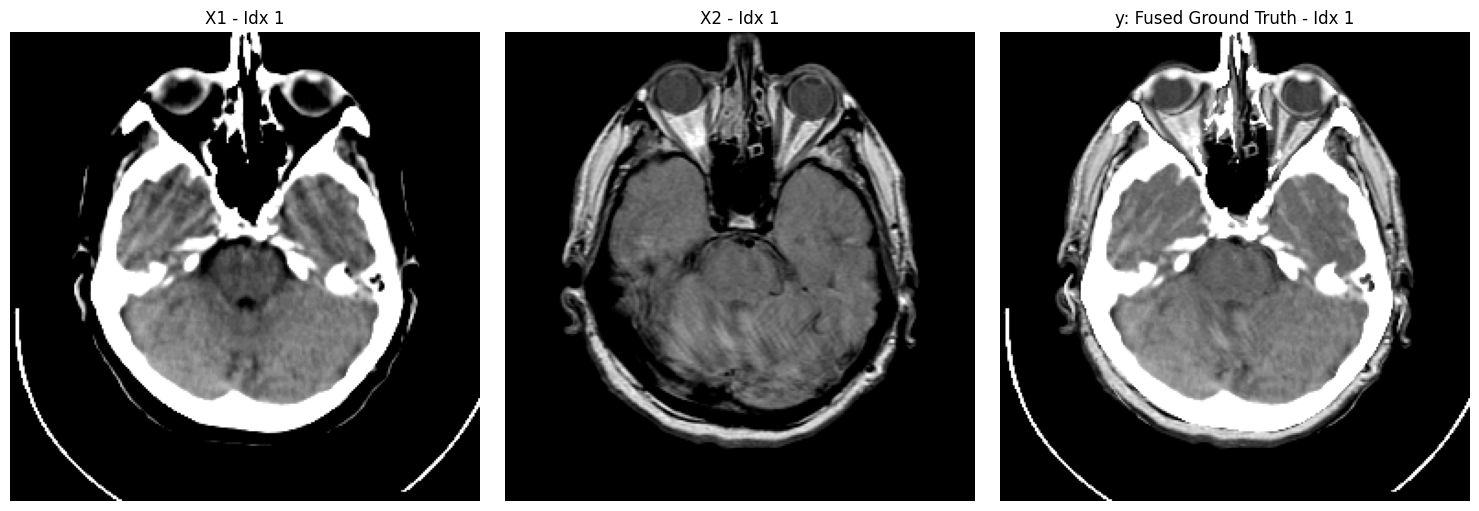

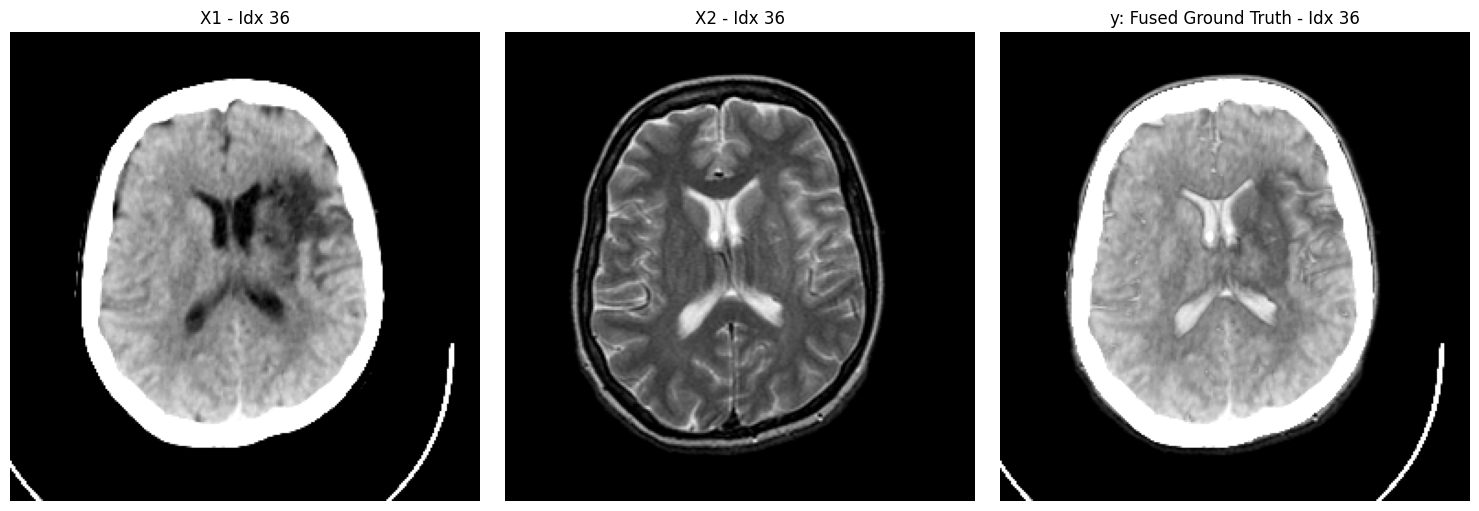

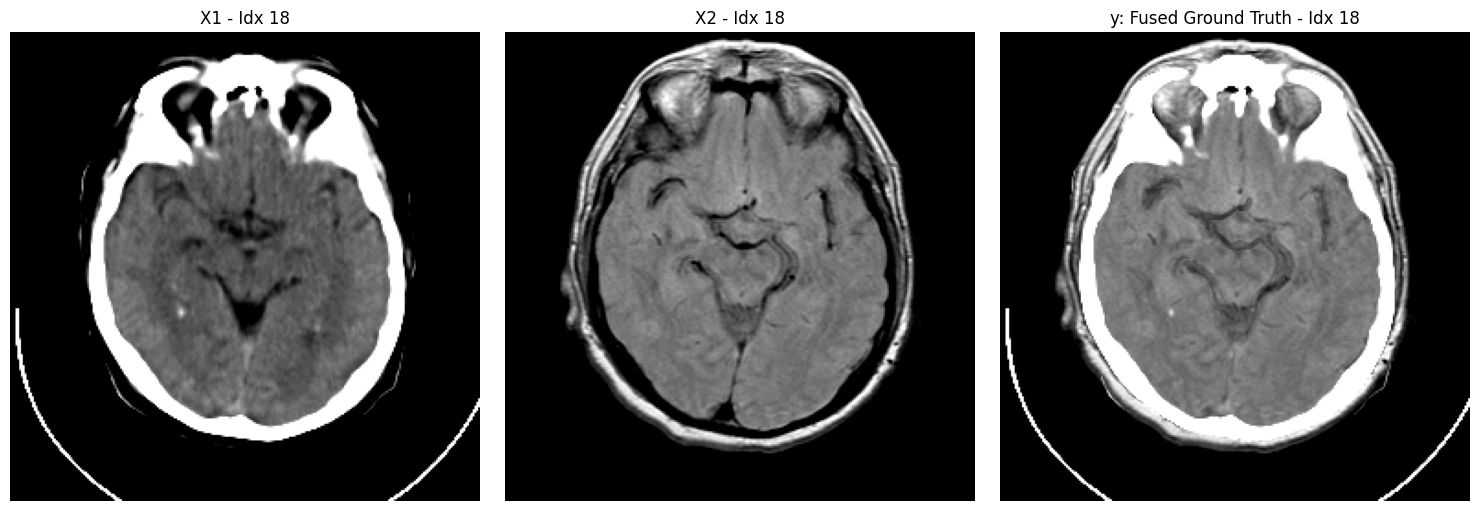

In [5]:
import random

def plot_fusion_triplet(x1_array, x2_array, target_array, num_samples=2):
    """
    Plots a row of [X1, X2, Fused Target] to verify alignment and color logic.
    """
    # Pick random indices to check
    # random.seed(213)
    indices = random.sample(range(len(x1_array)), num_samples)
    
    plt.figure(figsize=(15, 5 * num_samples))
    
    for row, idx in enumerate(indices):
        # Scale down to [0.0, 1.0] solely for matplotlib's float32 rendering requirements
        img_mri = x1_array[idx] / 255.0
        img_pet = x2_array[idx] / 255.0
        img_fused = target_array[idx] / 255.0
        
        # Plot X1
        plt.subplot(num_samples, 3, row * 3 + 1)
        plt.imshow(img_mri)
        plt.title(f"X1 - Idx {idx}")
        plt.axis('off')
        
        # Plot X2
        plt.subplot(num_samples, 3, row * 3 + 2)
        plt.imshow(img_pet)
        plt.title(f"X2 - Idx {idx}")
        plt.axis('off')
        
        # Plot y (Fused Target)
        plt.subplot(num_samples, 3, row * 3 + 3)
        plt.imshow(img_fused)
        plt.title(f"y: Fused Ground Truth - Idx {idx}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the plotter to check your training data!
plot_fusion_triplet(X1_test, X2_test, y_test, num_samples=1)
plot_fusion_triplet(X1_train, X2_train, y_train, num_samples=1)
plot_fusion_triplet(X1_val, X2_val, y_val, num_samples=1)

### Image Normalization

In [6]:
import numpy as np
from tensorflow.keras.applications.resnet_v2 import preprocess_input

print("--- Initial Data State Check ---")
print(f"X1_train initial range: Min = {X1_train.min():.4f}, Max = {X1_train.max():.4f}")
print(f"y_train initial range:  Min = {y_train.min():.4f}, Max = {y_train.max():.4f}")

# 1. Target Normalization (Brings labels/targets from [0, 255] to [0.0, 1.0])
if y_train.max() > 1.0:
    print("\nNormalizing target masks to [0.0, 1.0] range...")
    y_train = y_train.astype(np.float32) / 255.0
    y_test  = y_test.astype(np.float32) / 255.0
    y_val   = y_val.astype(np.float32) / 255.0
else:
    print("\nTargets are already normalized between [0, 1]. Skipping to avoid re-scaling.")

# 2. Input Image Normalization for ResNet50V2 
# Maps raw [0, 255] inputs to [-1.0, 1.0] range safely.
if X1_train.max() > 1.0:
    print("Applying ResNetV2 preprocessing to input image arrays...")
    
    # Cast to float32 before preprocessing to maintain mathematical precision
    X1_train = preprocess_input(X1_train.astype(np.float32))
    X1_test  = preprocess_input(X1_test.astype(np.float32))
    X1_val   = preprocess_input(X1_val.astype(np.float32))

    X2_train = preprocess_input(X2_train.astype(np.float32))
    X2_test  = preprocess_input(X2_test.astype(np.float32))
    X2_val   = preprocess_input(X2_val.astype(np.float32))
else:
    print("Inputs are already preprocessed in the [-1, 1] range. Skipping to prevent data collapse.")

print("\n--- Post-Normalization Data State Check ---")
print(f"X1_train processed range: Min = {X1_train.min():.4f}, Max = {X1_train.max():.4f}")
print(f"X2_train processed range: Min = {X2_train.min():.4f}, Max = {X2_train.max():.4f}")
print(f"y_train processed range:  Min = {y_train.min():.4f}, Max = {y_train.max():.4f}")

--- Initial Data State Check ---
X1_train initial range: Min = 0.0000, Max = 255.0000
y_train initial range:  Min = 0.0000, Max = 255.0000

Normalizing target masks to [0.0, 1.0] range...
Applying ResNetV2 preprocessing to input image arrays...

--- Post-Normalization Data State Check ---
X1_train processed range: Min = -1.0000, Max = 1.0000
X2_train processed range: Min = -1.0000, Max = 1.0000
y_train processed range:  Min = 0.0000, Max = 1.0000


### Dynamic Runtime Augmentation

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the augmentation parameters
aug_args = dict(
    rotation_range=15,       # Rotate up to 10 degrees
    width_shift_range=0.1,  # Shift left/right by 5%
    height_shift_range=0.05, # Shift up/down by 5%
    zoom_range=0.05,         # Zoom in/out by 5%
    horizontal_flip=True,    # Left/Right flip is usually safe for most axial medical scans
    fill_mode='nearest'      # How to fill missing pixels after shifting
)

# 2. Instantiate generator
datagen = ImageDataGenerator(**aug_args)

seed_value = 42 # Must for synchronizing the generators
batch_size = 4 

# 3. Flow from the RAM arrays
x1_gen = datagen.flow(X1_train, batch_size=batch_size, seed=seed_value, shuffle=True)
x2_gen = datagen.flow(X2_train, batch_size=batch_size, seed=seed_value, shuffle=True)
target_gen = datagen.flow(y_train, batch_size=batch_size, seed=seed_value, shuffle=True)

# 3. Zip them into a Dual-Stream Generator
def dual_stream_train_generator(x1_gen, x2_gen, t_gen):
    while True:
        # Must use a Dictionary matching Input(name="...") layers 
        inputs_dict = {
            "input_x1": next(x1_gen),
            "input_x2": next(x2_gen)
        }
        
        yield (inputs_dict, next(t_gen))

train_fusion_gen = dual_stream_train_generator(x1_gen, x2_gen, target_gen)

# (Optional) Test the generator to make sure the shapes are correct
sample_inputs, sample_targets = next(train_fusion_gen)

print(f"Input 1 shape: {sample_inputs['input_x1'].shape}") # Should be (batch_size, x, x, 3)
print(f"Input 2 shape: {sample_inputs['input_x2'].shape}") # Should be (batch_size, x, x, 3)
print(f"Target batch shape:  {sample_targets.shape}")   # Should be (batch_size, x, x, 3)

Input 1 shape: (4, 256, 256, 3)
Input 2 shape: (4, 256, 256, 3)
Target batch shape:  (4, 256, 256, 3)


## Model Creation

### Model Structure

In [8]:
from tensorflow.keras import applications as app
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Activation, BatchNormalization, Concatenate

# --- Stage 1: MULTI-STREAM ENCODER ---

# Left Stream encoder (ResNet50V2)
input_x1 = Input(shape=X1_val.shape[1:], name="input_x1")
left_encoder = app.ResNet50V2(weights='imagenet', include_top=False, input_tensor=input_x1)

# Setting unique names for each layer to avoid duplicate naming conflicts
for layer in left_encoder.layers[1:]:
    layer.name = layer.name + "_left"

left_fmap = left_encoder.output

# Right Stream encoder (ResNet50V2)
input_x2 = Input(shape=X2_val.shape[1:], name="input_x2")
right_encoder = app.ResNet50V2(weights='imagenet', include_top=False, input_tensor=input_x2)

# Setting unique names for each layer to avoid duplicate naming conflicts
for layer in right_encoder.layers[1:]:
    layer.name = layer.name + "_right"

right_fmap = right_encoder.output


# --- Stage 2: FEATURE FUSION ---

if int(left_fmap.shape[-2]) != int(right_fmap.shape[-2]):
    raise ValueError(f"Incompatible Encoders: The twin stream shapes do not match.")
    
combined_fmap = Concatenate(axis=-1, name="feature_map_combine")([left_fmap, right_fmap])

# Params for Decoder
fmap = min(2048, int(left_fmap.shape[-1]) + int(right_fmap.shape[-1])) 
res = int(combined_fmap.shape[-2])
target_res = int(y_val.shape[1])

# Feature Refiner
x = Conv2D(fmap, kernel_size=(3, 3), padding='same', name="feature_map_refiner")(combined_fmap)
x = BatchNormalization()(x)
x = Activation('relu')(x)


# --- Stage 3: DYNAMIC CUSTOM U-NET DECODER ---

# Image reconstruction
while res < target_res:
    res *= 2
    fmap = max(16, int(fmap / 2))

    # Deconvolution and Upscaling
    x = Conv2DTranspose(fmap, kernel_size=(3, 3), padding='same', strides=2, name=f"decoder_{res}")(x)
    
    # Dynamic Search for the Skip Connection on Left Stream
    target_layer_name_left = None
    
    # Traverse backwards to find the deepest layer at the target resolution
    for layer in left_encoder.layers[::-1]:
        shape = layer.output.shape
        if len(shape) == 4 and shape[1] == res and shape[2] == res:
            target_layer_name_left = layer.name
            break
            
    if target_layer_name_left is None:
        raise ValueError(f"Unsupported Encoder: Could not find a valid 4D skip connection layer for resolution {res}x{res} inside the left stream encoder.")

    left_skip_tensor = left_encoder.get_layer(target_layer_name_left).output

    # Dynamic Search for the Skip Connection on Right Stream
    target_layer_name_right = None
    
    # Traverse backwards to find the deepest layer at the target resolution
    for layer in right_encoder.layers[::-1]:
        shape = layer.output.shape
        if len(shape) == 4 and shape[1] == res and shape[2] == res:
            target_layer_name_right = layer.name
            break
            
    if target_layer_name_right is None:
        raise ValueError(f"Unsupported Encoder: Could not find a valid 4D skip connection layer for resolution {res}x{res} inside the right stream encoder.")

    right_skip_tensor = right_encoder.get_layer(target_layer_name_right).output
    
    print(f"Linking Skip Connection at {res}x{res}: decoder_{res} + {target_layer_name_left} + {target_layer_name_right}")
    
    # Combining Skip Connection with upscaled map
    x = Concatenate(axis=-1, name=f"skip_concat_{res}")([x, left_skip_tensor, right_skip_tensor])
    
    # Upscaled map refiner
    x = Conv2D(fmap, kernel_size=(3, 3), padding='same', name=f"decoder_refine_{res}")(x) 
    x = BatchNormalization()(x)
    x = Activation('relu')(x)


# --- Stage 4: (Optional) FINAL IMAGE REFINER ---
while fmap > 16:
    fmap = int(fmap / 2)
    x = Conv2D(fmap, kernel_size=(3, 3), padding='same', name=f"opt_refiner_{fmap}")(x) 
    x = BatchNormalization()(x)
    x = Activation('relu')(x)


# Final Output Layer: 1x1 Conv to collapse to 3 channels, Sigmoid for 0.0 to 1.0 mapping
fused_output = Conv2D(3, kernel_size=(1, 1), activation='sigmoid', name="fused_output")(x)

# Build and Instantiate the Model
fusion_model = Model(inputs=[input_x1, input_x2], outputs=fused_output, name="ResNetFusionNet")
fusion_model.summary()

I0000 00:00:1783087932.501140      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Linking Skip Connection at 16x16: decoder_16 + conv4_block6_1_relu_left + conv4_block6_1_relu_right
Linking Skip Connection at 32x32: decoder_32 + conv3_block4_1_relu_left + conv3_block4_1_relu_right
Linking Skip Connection at 64x64: decoder_64 + conv2_block3_1_relu_left + conv2_block3_1_relu_right
Linking Skip Connection at 128x128: decoder_128 + conv1_conv_left + conv1_conv_right
Linking Skip Connection at 256x256: decoder_256 + input_x1 + input_x2


Model: "ResNetFusionNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_x1            │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_x2            │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad_left      │ (None, 262, 262,  │          0 │ input_x1[0][0]    │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad_right     │ (None, 262, 262,  │          0 │ input_x2[0][0]    │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv_left     │ (None, 128, 128,  │      9,472 │ conv1_pad_left[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv_right    │ (None, 128, 128,  │      9,472 │ conv1_pad_right[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad_left      │ (None, 130, 130,  │          0 │ conv1_conv_left[… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad_right     │ (None, 130, 130,  │          0 │ conv1_conv_right… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool_left     │ (None, 64, 64,    │          0 │ pool1_pad_left[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool_right    │ (None, 64, 64,    │          0 │ pool1_pad_right[… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 64, 64,    │        256 │ pool1_pool_left[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 64, 64,    │        256 │ pool1_pool_right… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 64, 64,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 64, 64,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_con… │ (None, 64, 64,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_con… │ (None, 64, 64,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn_… │ (None, 64, 64,    │        256 │ conv2_block1_1_c

 Total params: 166,728,483 (636.02 MB)

 Trainable params: 166,629,443 (635.64 MB)

 Non-trainable params: 99,040 (386.88 KB)

### Loss Function and Evaluation Metrics

In [9]:
import tensorflow as tf
import numpy as np

def fusion_loss(y_true, y_pred):
    """
    Computes: RGB L1_Loss + 0.5 * Luminance_Edge_Loss
    """
    # 1. Base L1 Loss (Color + Structure)
    # Applies to all 3 RGB channels to guarantee pixel-perfect color reconstruction
    l1_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
    
    # 2. Isolate Structure for Edge Detection
    # tf.image.rgb_to_grayscale mathematically extracts the Y (Luminance) channel.
    # Shape converts from [batch, h, w, 3] to [batch, h, w, 1]
    y_true_luma = tf.image.rgb_to_grayscale(y_true)
    y_pred_luma = tf.image.rgb_to_grayscale(y_pred)
    
    # 3. Edge Loss using Sobel Filters strictly on the Luminance channel
    # This prevents the network from hallucinating edge artifacts inside the smooth PET thermal clouds
    sobel_true = tf.image.sobel_edges(y_true_luma)
    sobel_pred = tf.image.sobel_edges(y_pred_luma)
    
    edge_loss = tf.reduce_mean(tf.abs(sobel_true - sobel_pred))
    
    # 4. Combine them
    total_loss = l1_loss + (0.5 * edge_loss)
    
    return total_loss
    

# 1. PSNR (Peak Signal-to-Noise Ratio)
def psnr(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

# 2. SSIM (Structural Similarity Index Measure)
def ssim(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

# 3. Mutual Information (MI)
def numpy_mutual_information(y_true, y_pred):
    """
    Standard numpy implementation of Mutual Information using a 2D joint histogram.
    """
    # It converts the entire RGB matrix into a continuous 1D distribution array.
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    # Calculate the 2D histogram (using 100 bins for continuous 0.0-1.0 values)
    hist_2d, _, _ = np.histogram2d(y_true_flat, y_pred_flat, bins=100)
    
    # Convert histogram counts to probabilities
    pxy = hist_2d / float(np.sum(hist_2d))
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    
    # Calculate MI only where probabilities are non-zero to avoid log(0)
    non_zeros = pxy > 0
    mi = np.sum(pxy[non_zeros] * np.log(pxy[non_zeros] / px_py[non_zeros]))
    
    return np.float32(mi)

## Warm Up Training

### Model Compilation

In [10]:
from tensorflow.keras.optimizers import Adam

# Freezing Encoder
left_encoder.trainable = False
right_encoder.trainable = False

# Compile the model
fusion_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=fusion_loss,
    metrics=[psnr]
)

### Callbacks

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

# Stops the training if the monitor metrics doesnt improves in specific patience epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-3, restore_best_weights=True)

### Training

In [12]:
train_steps = len(X1_train) // batch_size

print(f"Batch Size: {batch_size}")
print(f"Calculated Train Steps: {train_steps}")
print('')

print("Starting Warm Up...")
history_warmup = fusion_model.fit(
    train_fusion_gen,
    steps_per_epoch=train_steps,
    epochs=100,
    validation_data=([X1_val, X2_val], y_val),
    callbacks=[early_stopping]
)

Batch Size: 4
Calculated Train Steps: 32

Starting Warm Up...
Epoch 1/100


2026-07-03 14:12:43.922630: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 14:12:44.200757: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/32 ━━━━━━━━━━━━━━━━━━━━ 20:22 39s/step - loss: 0.5619 - psnr: 6.8792

I0000 00:00:1783087977.245750      70 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 66s 852ms/step - loss: 0.2843 - psnr: 11.3405 - val_loss: 0.5508 - val_psnr: 5.3556
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - loss: 0.1985 - psnr: 13.5365 - val_loss: 0.3441 - val_psnr: 9.6147
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - loss: 0.1557 - psnr: 15.4606 - val_loss: 0.2969 - val_psnr: 10.2245
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - loss: 0.1225 - psnr: 17.5079 - val_loss: 0.2161 - val_psnr: 12.6786
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - loss: 0.0987 - psnr: 19.6779 - val_loss: 0.1412 - val_psnr: 16.3544
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - loss: 0.0813 - psnr: 21.7116 - val_loss: 0.1128 - val_psnr: 18.6339
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - loss: 0.0665 - psnr: 23.6772 - val_loss: 0.0883 - val_psnr: 20.8531
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - loss: 0.0561 - psnr: 25.4655 - val_loss: 0.0704 - val_psnr: 24.0291
Epoch 9/100
32/32 ━━━━━━━━━━━

## Fine Tuning

### Model Compilation

In [13]:
from tensorflow.keras.optimizers import Adam

# Define how much last layers will be fine-tuned
percent_of_layers_to_train = 25
to_be_trained_left = int((percent_of_layers_to_train/100)*len(left_encoder.layers))
to_be_trained_right = int((percent_of_layers_to_train/100)*len(right_encoder.layers))

print(f"Trainable Layers for Left Stream : {to_be_trained_left}")
print(f"Trainable Layers for Right Stream : {to_be_trained_right}")

for layer in left_encoder.layers[:-to_be_trained_left]:
    layer.trainable = False

for layer in left_encoder.layers[-to_be_trained_left:]:
    layer.trainable = True

for layer in right_encoder.layers[:-to_be_trained_right]:
    layer.trainable = False

for layer in right_encoder.layers[-to_be_trained_right:]:
    layer.trainable = True


# Compile the model
fusion_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=fusion_loss,
    metrics=[psnr]
)

Trainable Layers for Left Stream : 47
Trainable Layers for Right Stream : 47


### Callbacks

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Saves the model automatically whenever the validation loss hits a new all-time low
model_checkpoint = ModelCheckpoint(filepath='/kaggle/working/fusion_model_best.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=0)

# Reduces the learning rate by multiplying with the defined factor if the monitor metrics doesnt improves in specific patience epochs
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.75, patience=5, min_lr=1e-6)

# Stops the training if the monitor metrics doesnt improves in specific patience epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=30, min_delta=1e-4, restore_best_weights=True)

### Training

In [15]:
# Calculate Steps
train_steps = len(X1_train) // batch_size

print(f"Batch Size: {batch_size}")
print(f"Calculated Train Steps: {train_steps}")
print('')

# The Training Loop
print("Starting Fine Tunning...")
history_finetune = fusion_model.fit(
    train_fusion_gen,
    steps_per_epoch=train_steps,
    epochs=500,
    validation_data=([X1_val, X2_val], y_val),
    callbacks=[model_checkpoint, lr_schedule, early_stopping]
)

Batch Size: 4
Calculated Train Steps: 32

Starting Fine Tunning...
Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 67s 746ms/step - loss: 0.0138 - psnr: 37.6623 - val_loss: 0.0136 - val_psnr: 36.7694 - learning_rate: 1.0000e-04
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 490ms/step - loss: 0.0124 - psnr: 38.9248 - val_loss: 0.0133 - val_psnr: 36.9207 - learning_rate: 1.0000e-04
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - loss: 0.0126 - psnr: 38.5117 - val_loss: 0.0136 - val_psnr: 36.8168 - learning_rate: 1.0000e-04
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 522ms/step - loss: 0.0129 - psnr: 38.5007 - val_loss: 0.0131 - val_psnr: 37.0397 - learning_rate: 1.0000e-04
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - loss: 0.0126 - psnr: 38.7611 - val_loss: 0.0136 - val_psnr: 36.7000 - learning_rate: 1.0000e-04
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - loss: 0.0124 - psnr: 38.7491 - val_loss: 0.0133 - val_psnr: 36.9763 - learning_rate: 1.0000e-04
Epoch 7/500
32/32 ━━━━━━

## Result and Visualization

### Final Result on TestSet

In [16]:
# Final Result

print("Running predictions...")

# Pass the dual-stream inputs as a Python list
y_pred_all = fusion_model.predict([X1_test, X2_test], batch_size=batch_size)
y_pred_all = np.clip(y_pred_all, 0.0, 1.0) # Ensure strict 0-1 bounds

# Convert numpy arrays to tensors for the TF functions
y_true_tensor = tf.constant(y_test, dtype=tf.float32)
y_pred_tensor = tf.constant(y_pred_all, dtype=tf.float32)

# fusion_loss naturally returns a single mean value
final_loss = fusion_loss(y_true_tensor, y_pred_tensor).numpy()

# psnr and ssim return an array of scores (one for each image in the array). 
# use tf.reduce_mean to average them into a single final score.
final_psnr = tf.reduce_mean(psnr(y_true_tensor, y_pred_tensor)).numpy()
final_ssim = tf.reduce_mean(ssim(y_true_tensor, y_pred_tensor)).numpy()

final_mi = numpy_mutual_information(y_test, y_pred_all)

# Print Results
print("\n" + "="*40)
print("          FINAL TEST RESULTS")
print("="*40)
print(f"Test Loss (L1 + Edge) : {final_loss:.5f}")
print(f"Test PSNR             : {final_psnr:.4f} dB")
print(f"Test SSIM             : {final_ssim:.4f}")
print(f"Test Mutual Info (MI) : {final_mi:.4f}")
print("="*40)

Running predictions...
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step

          FINAL TEST RESULTS
Test Loss (L1 + Edge) : 0.01112
Test PSNR             : 38.1149 dB
Test SSIM             : 0.9923
Test Mutual Info (MI) : 1.7950


### Visualizion of Final Fused Image

Running inference...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

--- Diagnostic Range Stats ---
Raw Input X1 Test Batch Range: Min = -1.0000, Max = 1.0000
Raw Input X2 Test Batch Range: Min = -1.0000, Max = 1.0000
Model Predictions Output Range: Min = 0.0000, Max = 1.0000
-------------------------------



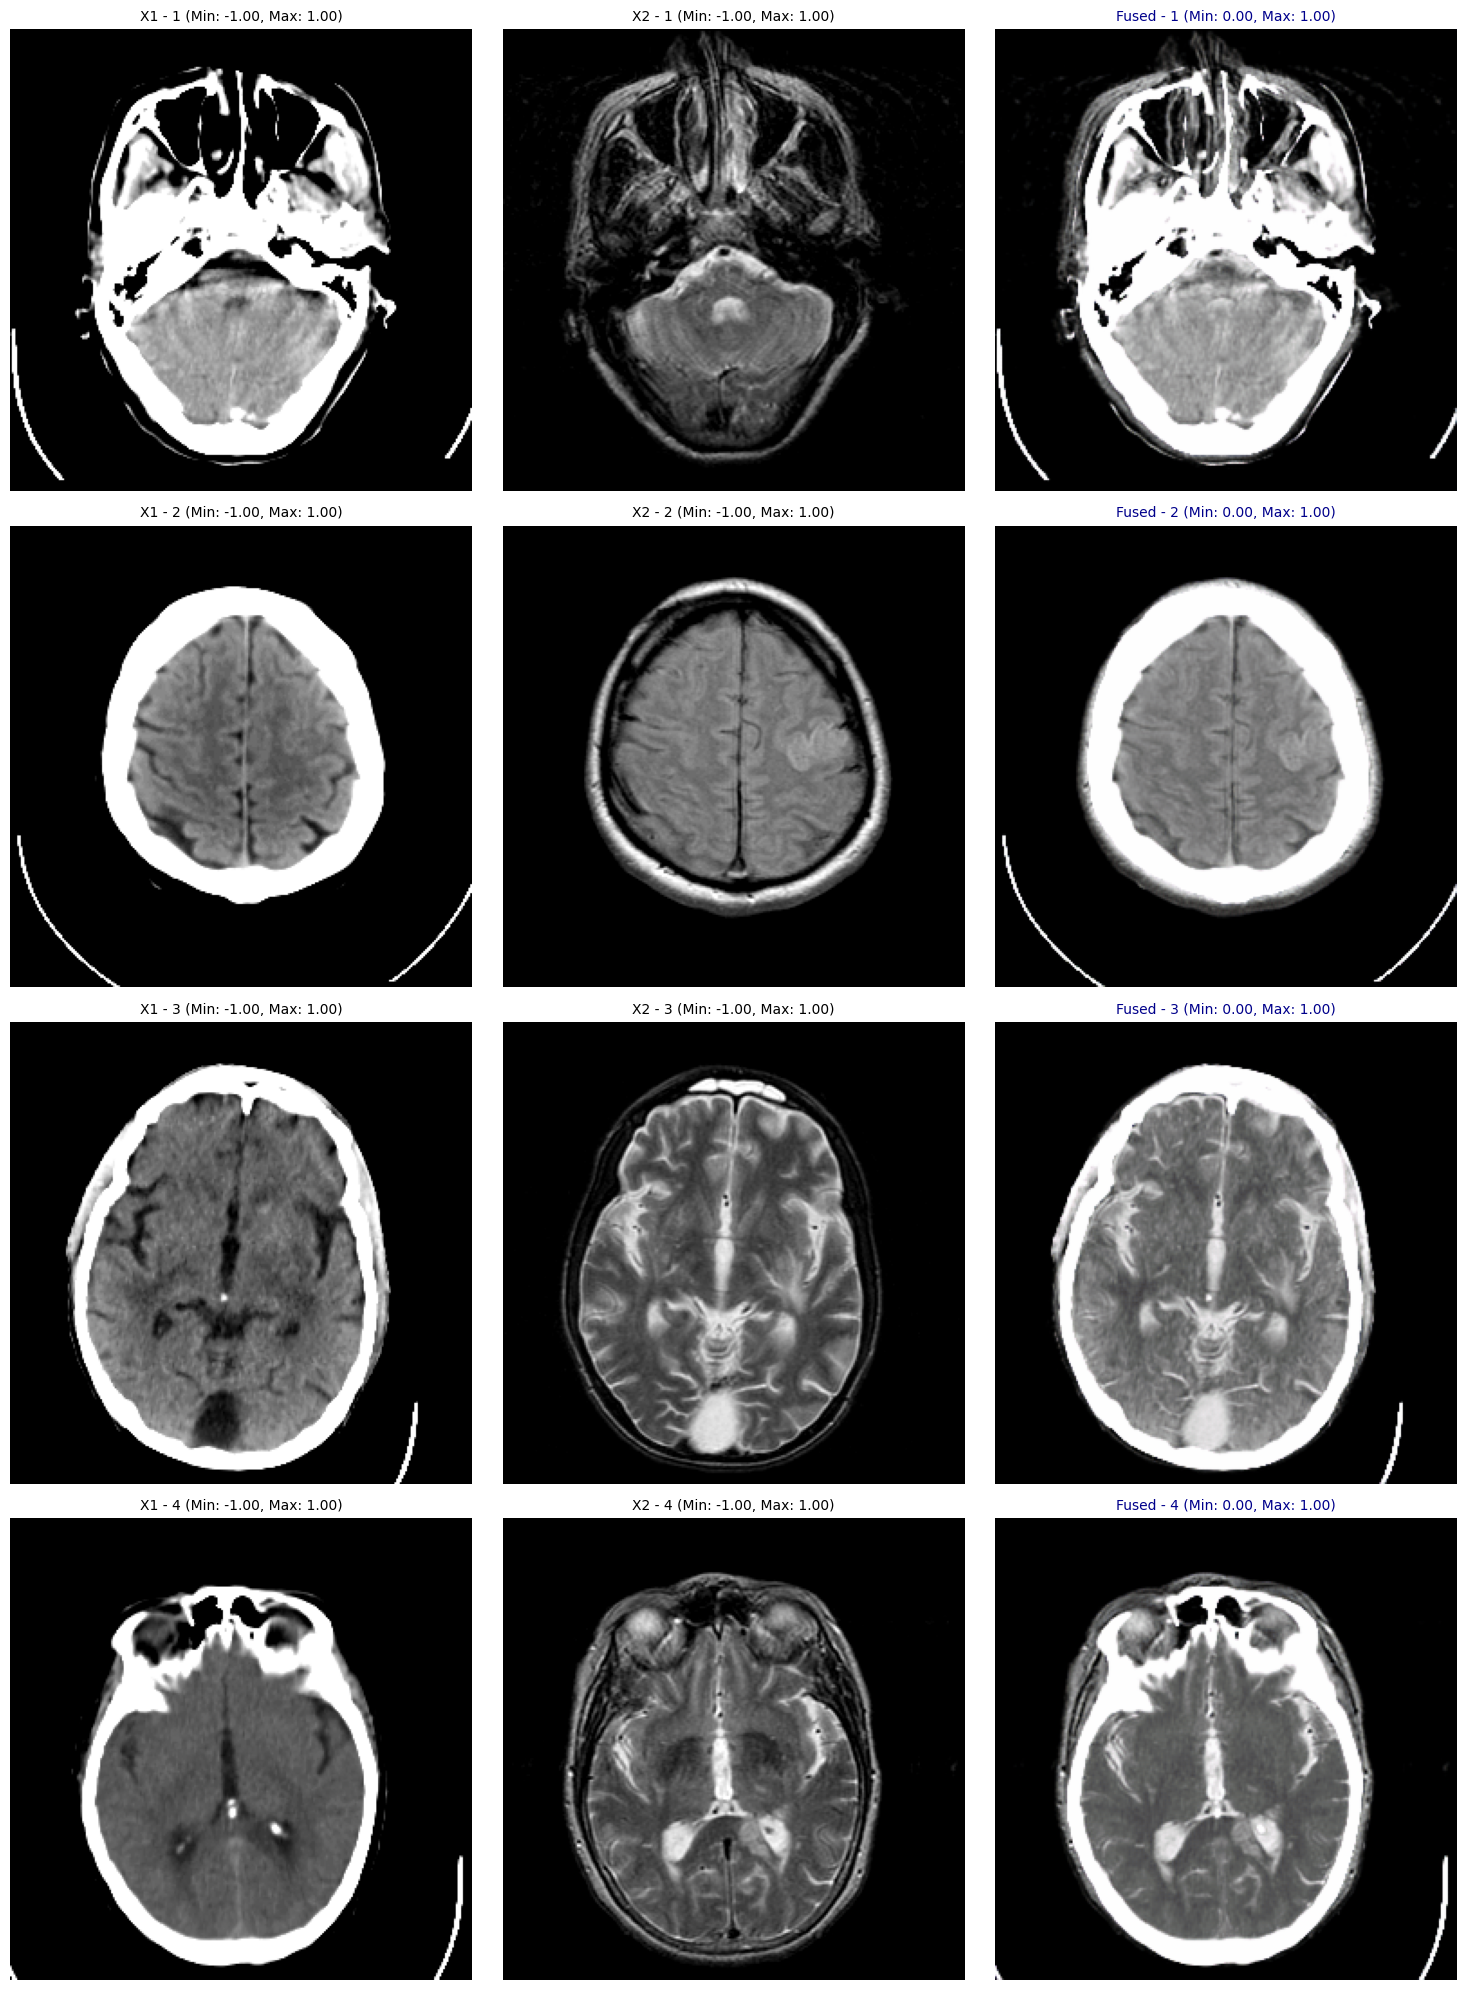

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def unprocess_image(img):
    """
    Robust helper to bring images from any range back to [0, 1] for matplotlib.
    """
    img_min, img_max = np.min(img), np.max(img)
    
    # Scenario A: Image is in ResNetV2 preprocessed range [-1, 1]
    if img_min < 0:
        return np.clip((img + 1.0) / 2.0, 0.0, 1.0)
    
    # Scenario B: Image is in raw pixel range [0, 255]
    elif img_max > 2.0:
        return np.clip(img / 255.0, 0.0, 1.0)
    
    # Scenario C: Image is already properly bound to [0, 1]
    else:
        return np.clip(img, 0.0, 1.0)

def show_fusion_results(x1_batch, x2_batch, fused_batch, num_images=4):
    """
    Plots the X1, X2, and Fused images side-by-side with safe un-processing.
    """
    num_images = min(num_images, x1_batch.shape[0])
    
    plt.figure(figsize=(15, 5 * num_images))
    for i in range(num_images):
        
        # Unprocess each image individually based on its actual value ranges
        x1_img = unprocess_image(x1_batch[i])
        x2_img = unprocess_image(x2_batch[i])
        fused_img = unprocess_image(fused_batch[i])
        
        # Plot X1 (Left)
        plt.subplot(num_images, 3, i * 3 + 1)
        plt.imshow(x1_img)
        plt.title(f"X1 - {i+1} (Min: {x1_batch[i].min():.2f}, Max: {x1_batch[i].max():.2f})", fontsize=10)
        plt.axis('off')
        
        # Plot X2 (Center)
        plt.subplot(num_images, 3, i * 3 + 2)
        plt.imshow(x2_img)
        plt.title(f"X2 - {i+1} (Min: {x2_batch[i].min():.2f}, Max: {x2_batch[i].max():.2f})", fontsize=10)
        plt.axis('off')
        
        # Plot Fused (Right)
        plt.subplot(num_images, 3, i * 3 + 3)
        plt.imshow(fused_img)
        plt.title(f"Fused - {i+1} (Min: {fused_batch[i].min():.2f}, Max: {fused_batch[i].max():.2f})", fontsize=10, color='darkblue')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# 1. Grab a random batch of 4 indices
num_samples = X1_test.shape[0]
random_indices = np.random.choice(num_samples, size=4, replace=False)

# 2. Sample the separate test arrays
x1_sample = X1_test[random_indices]
x2_sample = X2_test[random_indices]

# 3. Run Inference
print("Running inference...")
predictions = fusion_model.predict([x1_sample, x2_sample])

# 4. Check array diagnostic prints before plotting
print("\n--- Diagnostic Range Stats ---")
print(f"Raw Input X1 Test Batch Range: Min = {x1_sample.min():.4f}, Max = {x1_sample.max():.4f}")
print(f"Raw Input X2 Test Batch Range: Min = {x2_sample.min():.4f}, Max = {x2_sample.max():.4f}")
print(f"Model Predictions Output Range: Min = {predictions.min():.4f}, Max = {predictions.max():.4f}")
print("-------------------------------\n")

# 5. Plot the final results!
show_fusion_results(x1_sample, x2_sample, predictions, num_images=4)

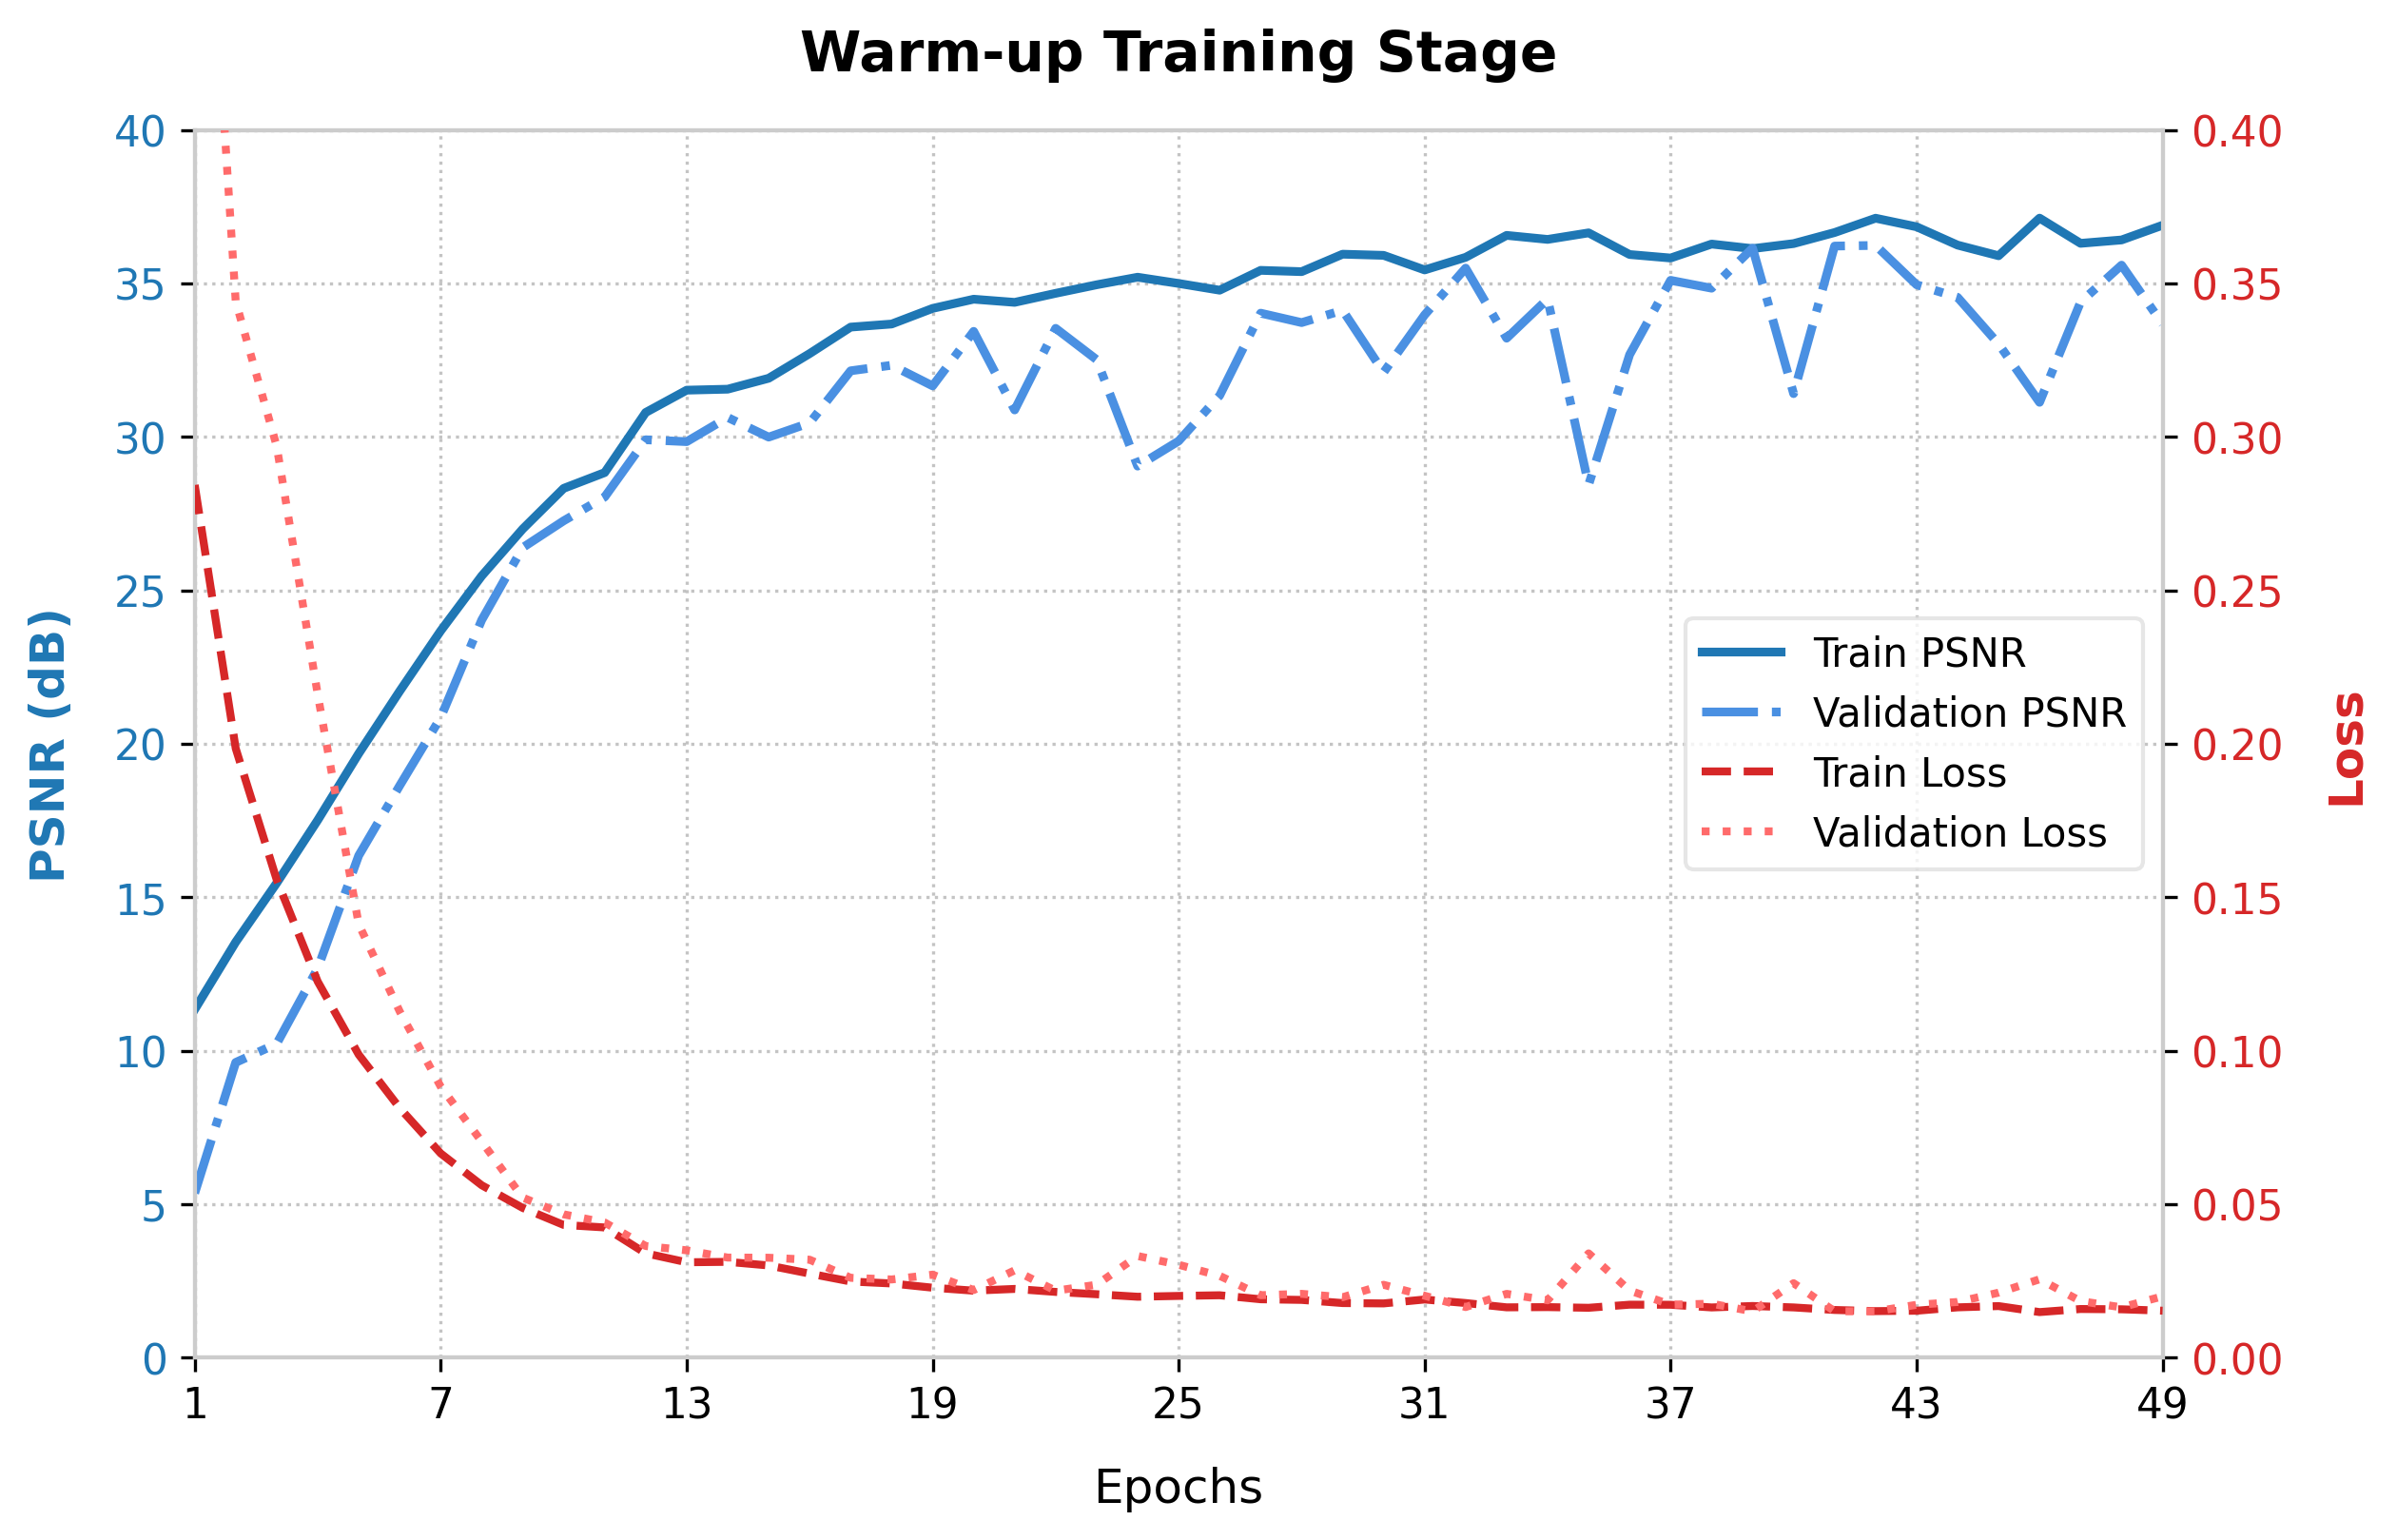

/kaggle/working/warm-up_training_stage_curve.png

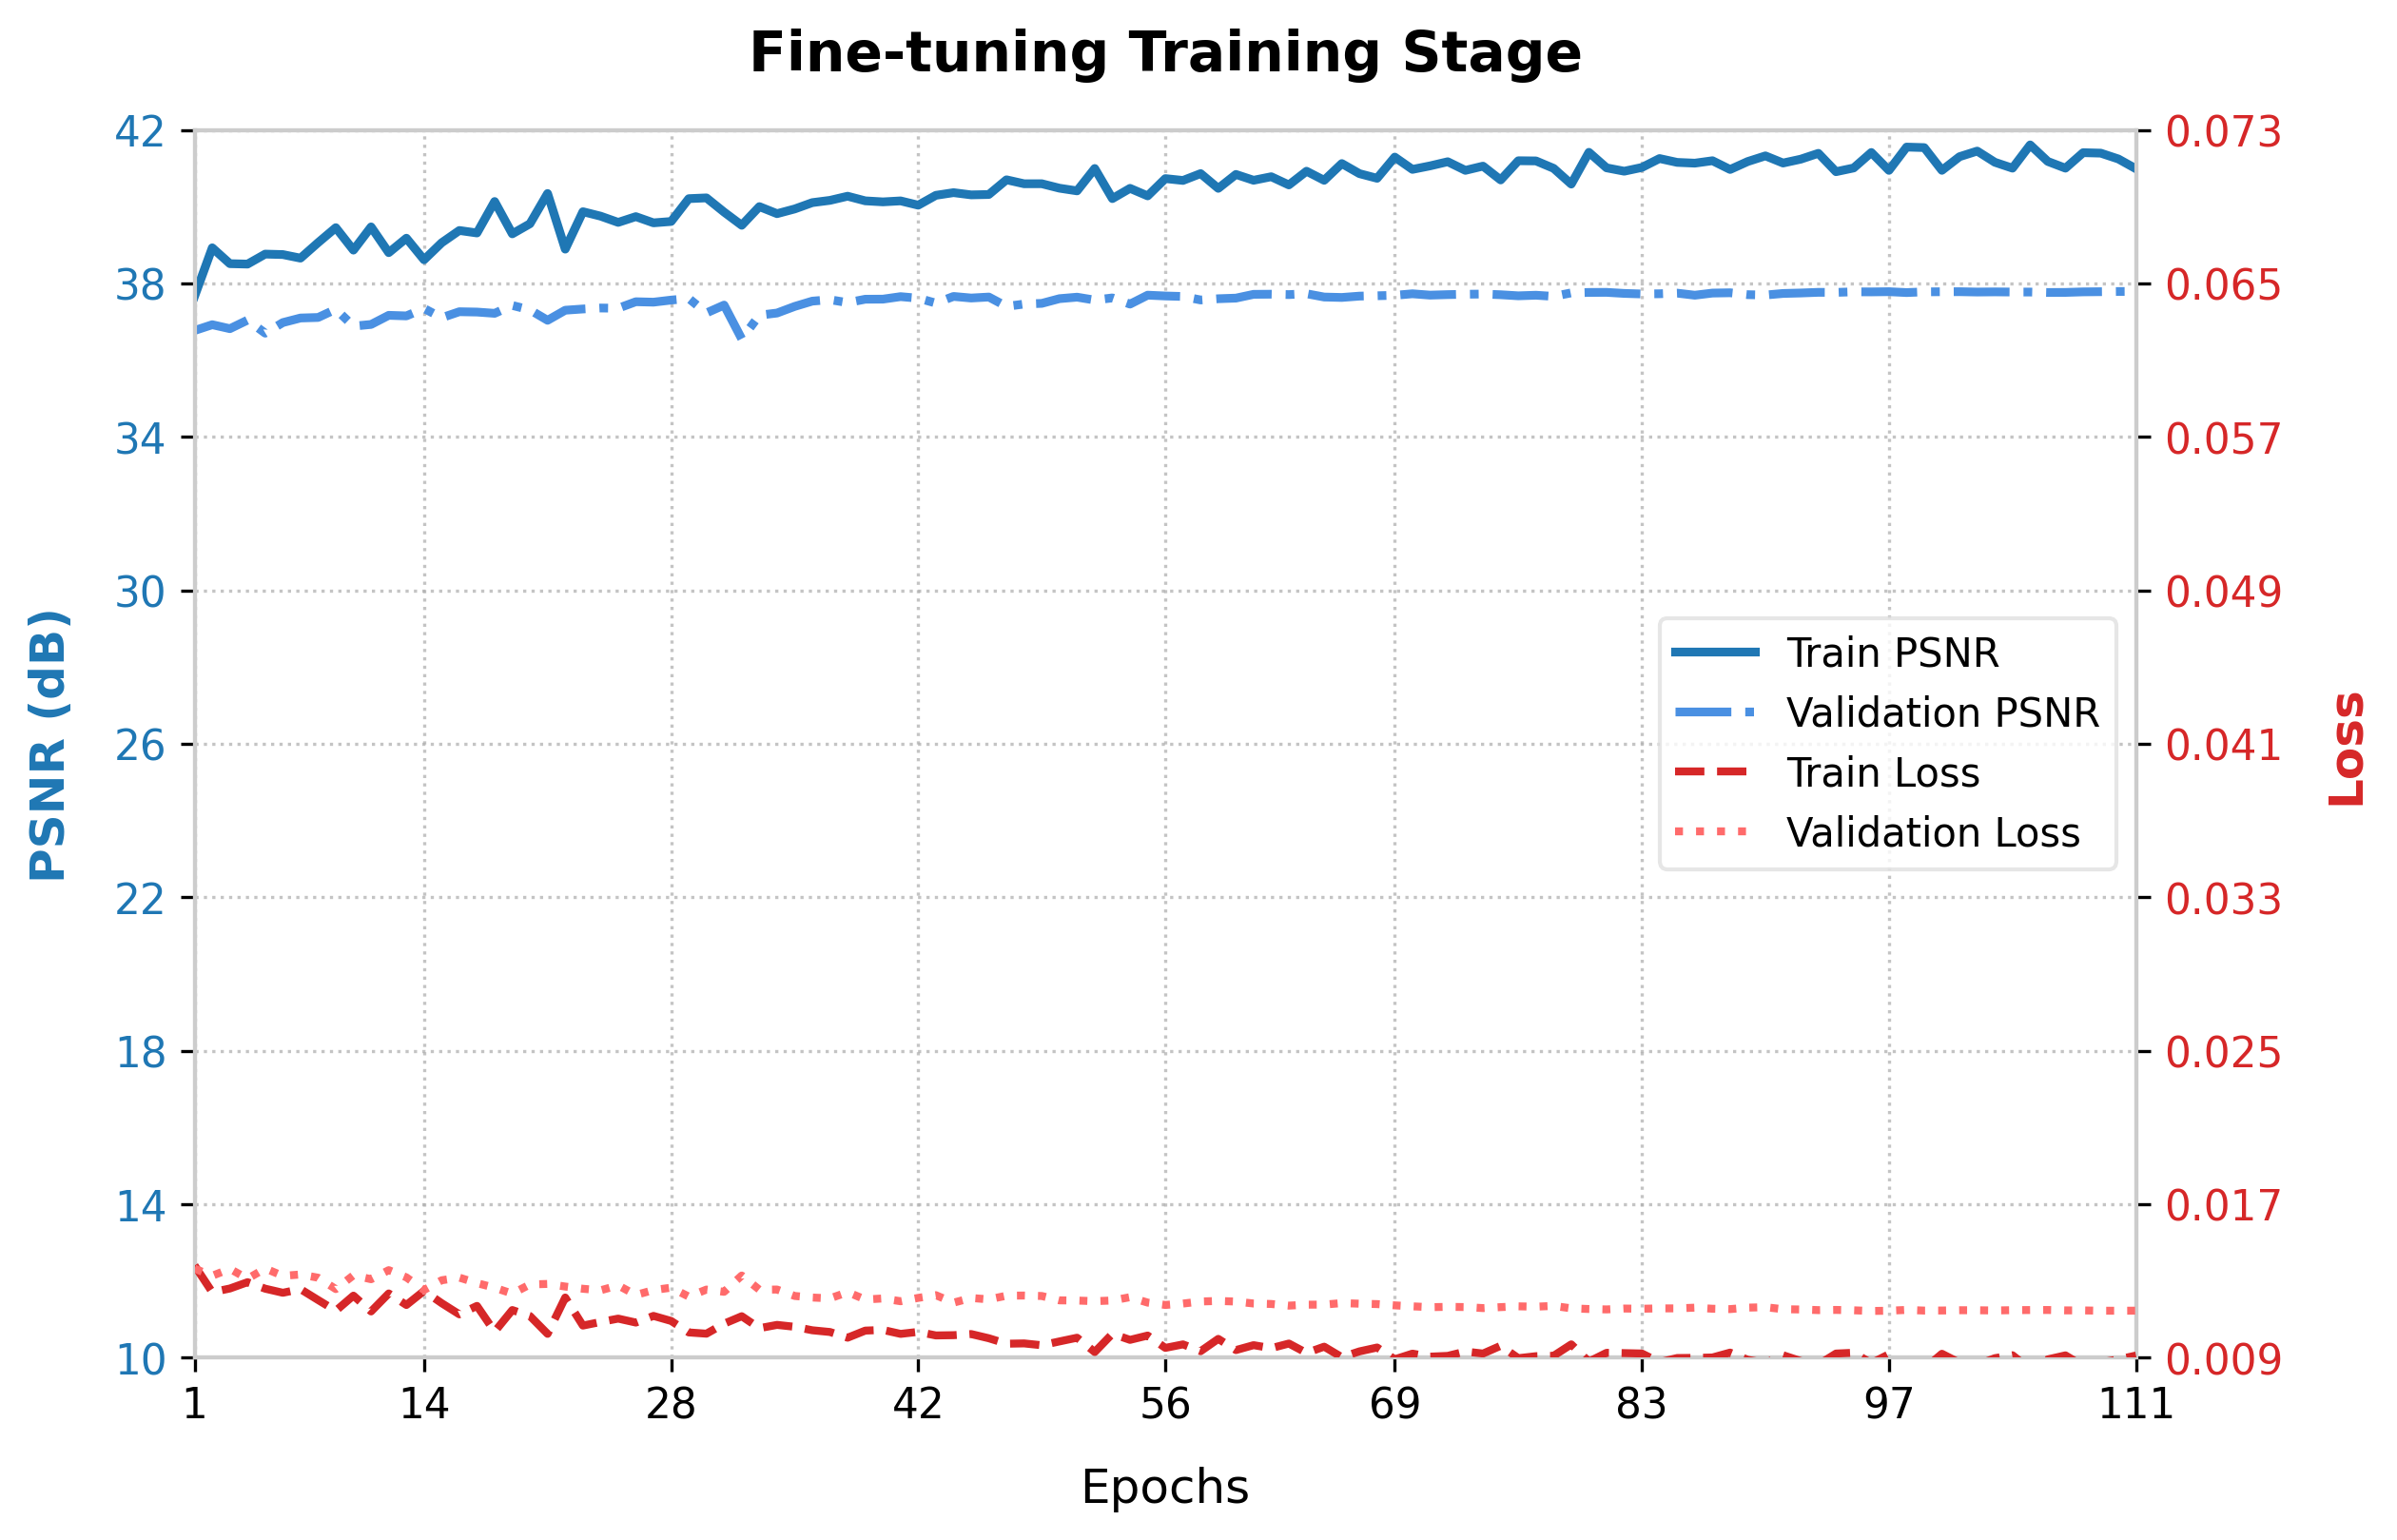

/kaggle/working/fine-tuning_training_stage_curve.png

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import FileLink, display

def plot_training_metrics_optimized(history_obj, title_name):
    """
    Generates publication-quality dual-axis plots with specific color grading.
    Both Warm-up and Fine-tuning stages are locked into a symmetric 8x8 grid matrix
    (8 X-axis intervals by 8 Y-axis intervals) with crisp integer labels for Epochs.
    """
    h = history_obj.history if hasattr(history_obj, 'history') else history_obj
    total_epochs = len(h['loss'])
    epochs = range(1, total_epochs + 1)
    
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.edgecolor'] = '#CCCCCC'
    plt.rcParams['axes.linewidth'] = 1.0
    
    fig, ax1 = plt.subplots(figsize=(8.5, 5.5), dpi=300)
    
    # ---------------- Left Y-Axis: PSNR Values (BLUE Theme) ----------------
    line1 = ax1.plot(epochs, h['psnr'], color='#1F77B4', linestyle='-', linewidth=2.2, label='Train PSNR', zorder=3)
    line2 = ax1.plot(epochs, h['val_psnr'], color='#4A90E2', linestyle='-.', linewidth=2.2, label='Validation PSNR', zorder=3)
    
    ax1.set_xlabel('Epochs', fontsize=12, labelpad=10)
    ax1.set_ylabel('PSNR (dB)', fontsize=12, labelpad=10, color='#1F77B4', fontweight='bold')
    
    # Force X-axis limits securely based on epoch length
    ax1.set_xlim(1, total_epochs)
    
    # AUTO-GRID: Force exactly 8 intervals, safely mapped to clean integers
    x_ticks = np.linspace(1, total_epochs, 9).astype(int)
    x_ticks = np.unique(x_ticks)  # Prevents duplicate ticks if total_epochs < 8
    ax1.set_xticks(x_ticks)
    
    # ---------------- Left Axis (PSNR) Bounds & Ticks ----------------
    if "Fine" in title_name:
        # Fine-tuning: Range 10 to 42 split into 8 intervals (steps of 4)
        ax1.set_ylim(10, 42)
        ax1.set_yticks(np.linspace(10, 42, 9))
    else:
        # Warm-up: Range 0 to 40 split into 8 intervals (steps of 5)
        ax1.set_ylim(0, 40)
        ax1.set_yticks(np.linspace(0, 40, 9))
        
    ax1.tick_params(axis='y', labelsize=10.5, labelcolor='#1F77B4')
    ax1.tick_params(axis='x', labelsize=10.5)
    
    # OPTIMIZED GRID: Forms a crisp symmetric matrix background
    ax1.grid(True, linestyle=':', alpha=0.75, color='#B0B0B0', linewidth=0.8, zorder=1)
    
    # ---------------- Right Y-Axis: Loss Values (RED Theme) ----------------
    ax2 = ax1.twinx()
    line3 = ax2.plot(epochs, h['loss'], color='#D62728', linestyle='--', linewidth=2.0, label='Train Loss', zorder=3)
    line4 = ax2.plot(epochs, h['val_loss'], color='#FF6B6B', linestyle=':', linewidth=2.0, label='Validation Loss', zorder=3)
    
    ax2.set_ylabel('Loss', fontsize=12, labelpad=10, color='#D62728', fontweight='bold')
    
    # ---------------- Right Axis (Loss) Bounds & Ticks ----------------
    if "Fine" in title_name:
        # Fine-tuning: Range 0.009 to 0.073 split into 8 intervals (steps of 0.008)
        ax2.set_ylim(0.009, 0.073)
        ax2.set_yticks(np.linspace(0.009, 0.073, 9))
    else:
        # Warm-up: Range 0.0 to 0.40 split into 8 intervals (steps of 0.05)
        ax2.set_ylim(0.0, 0.40)
        ax2.set_yticks(np.linspace(0.0, 0.40, 9))
        
    ax2.tick_params(axis='y', labelsize=10.5, labelcolor='#D62728')
    
    # ---------------- Legend Layout (Inside Frame) ----------------
    all_lines = line1 + line2 + line3 + line4
    all_labels = [l.get_label() for l in all_lines]
    
    leg = ax1.legend(
        all_lines, 
        all_labels, 
        loc='center right', 
        frameon=True, 
        facecolor='white', 
        edgecolor='#E0E0E0', 
        fontsize=10
    )
    
    if leg:
        leg.set_zorder(4)
    
    plt.title(title_name, fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    
    save_filename = title_name.lower().replace(' ', '_') + '_curve.png'
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    plt.show()
    return save_filename

# --- Execution Block ---
fn_warmup = plot_training_metrics_optimized(history_warmup, 'Warm-up Training Stage')
display(FileLink(fn_warmup))

fn_finetune = plot_training_metrics_optimized(history_finetune, 'Fine-tuning Training Stage')
display(FileLink(fn_finetune))

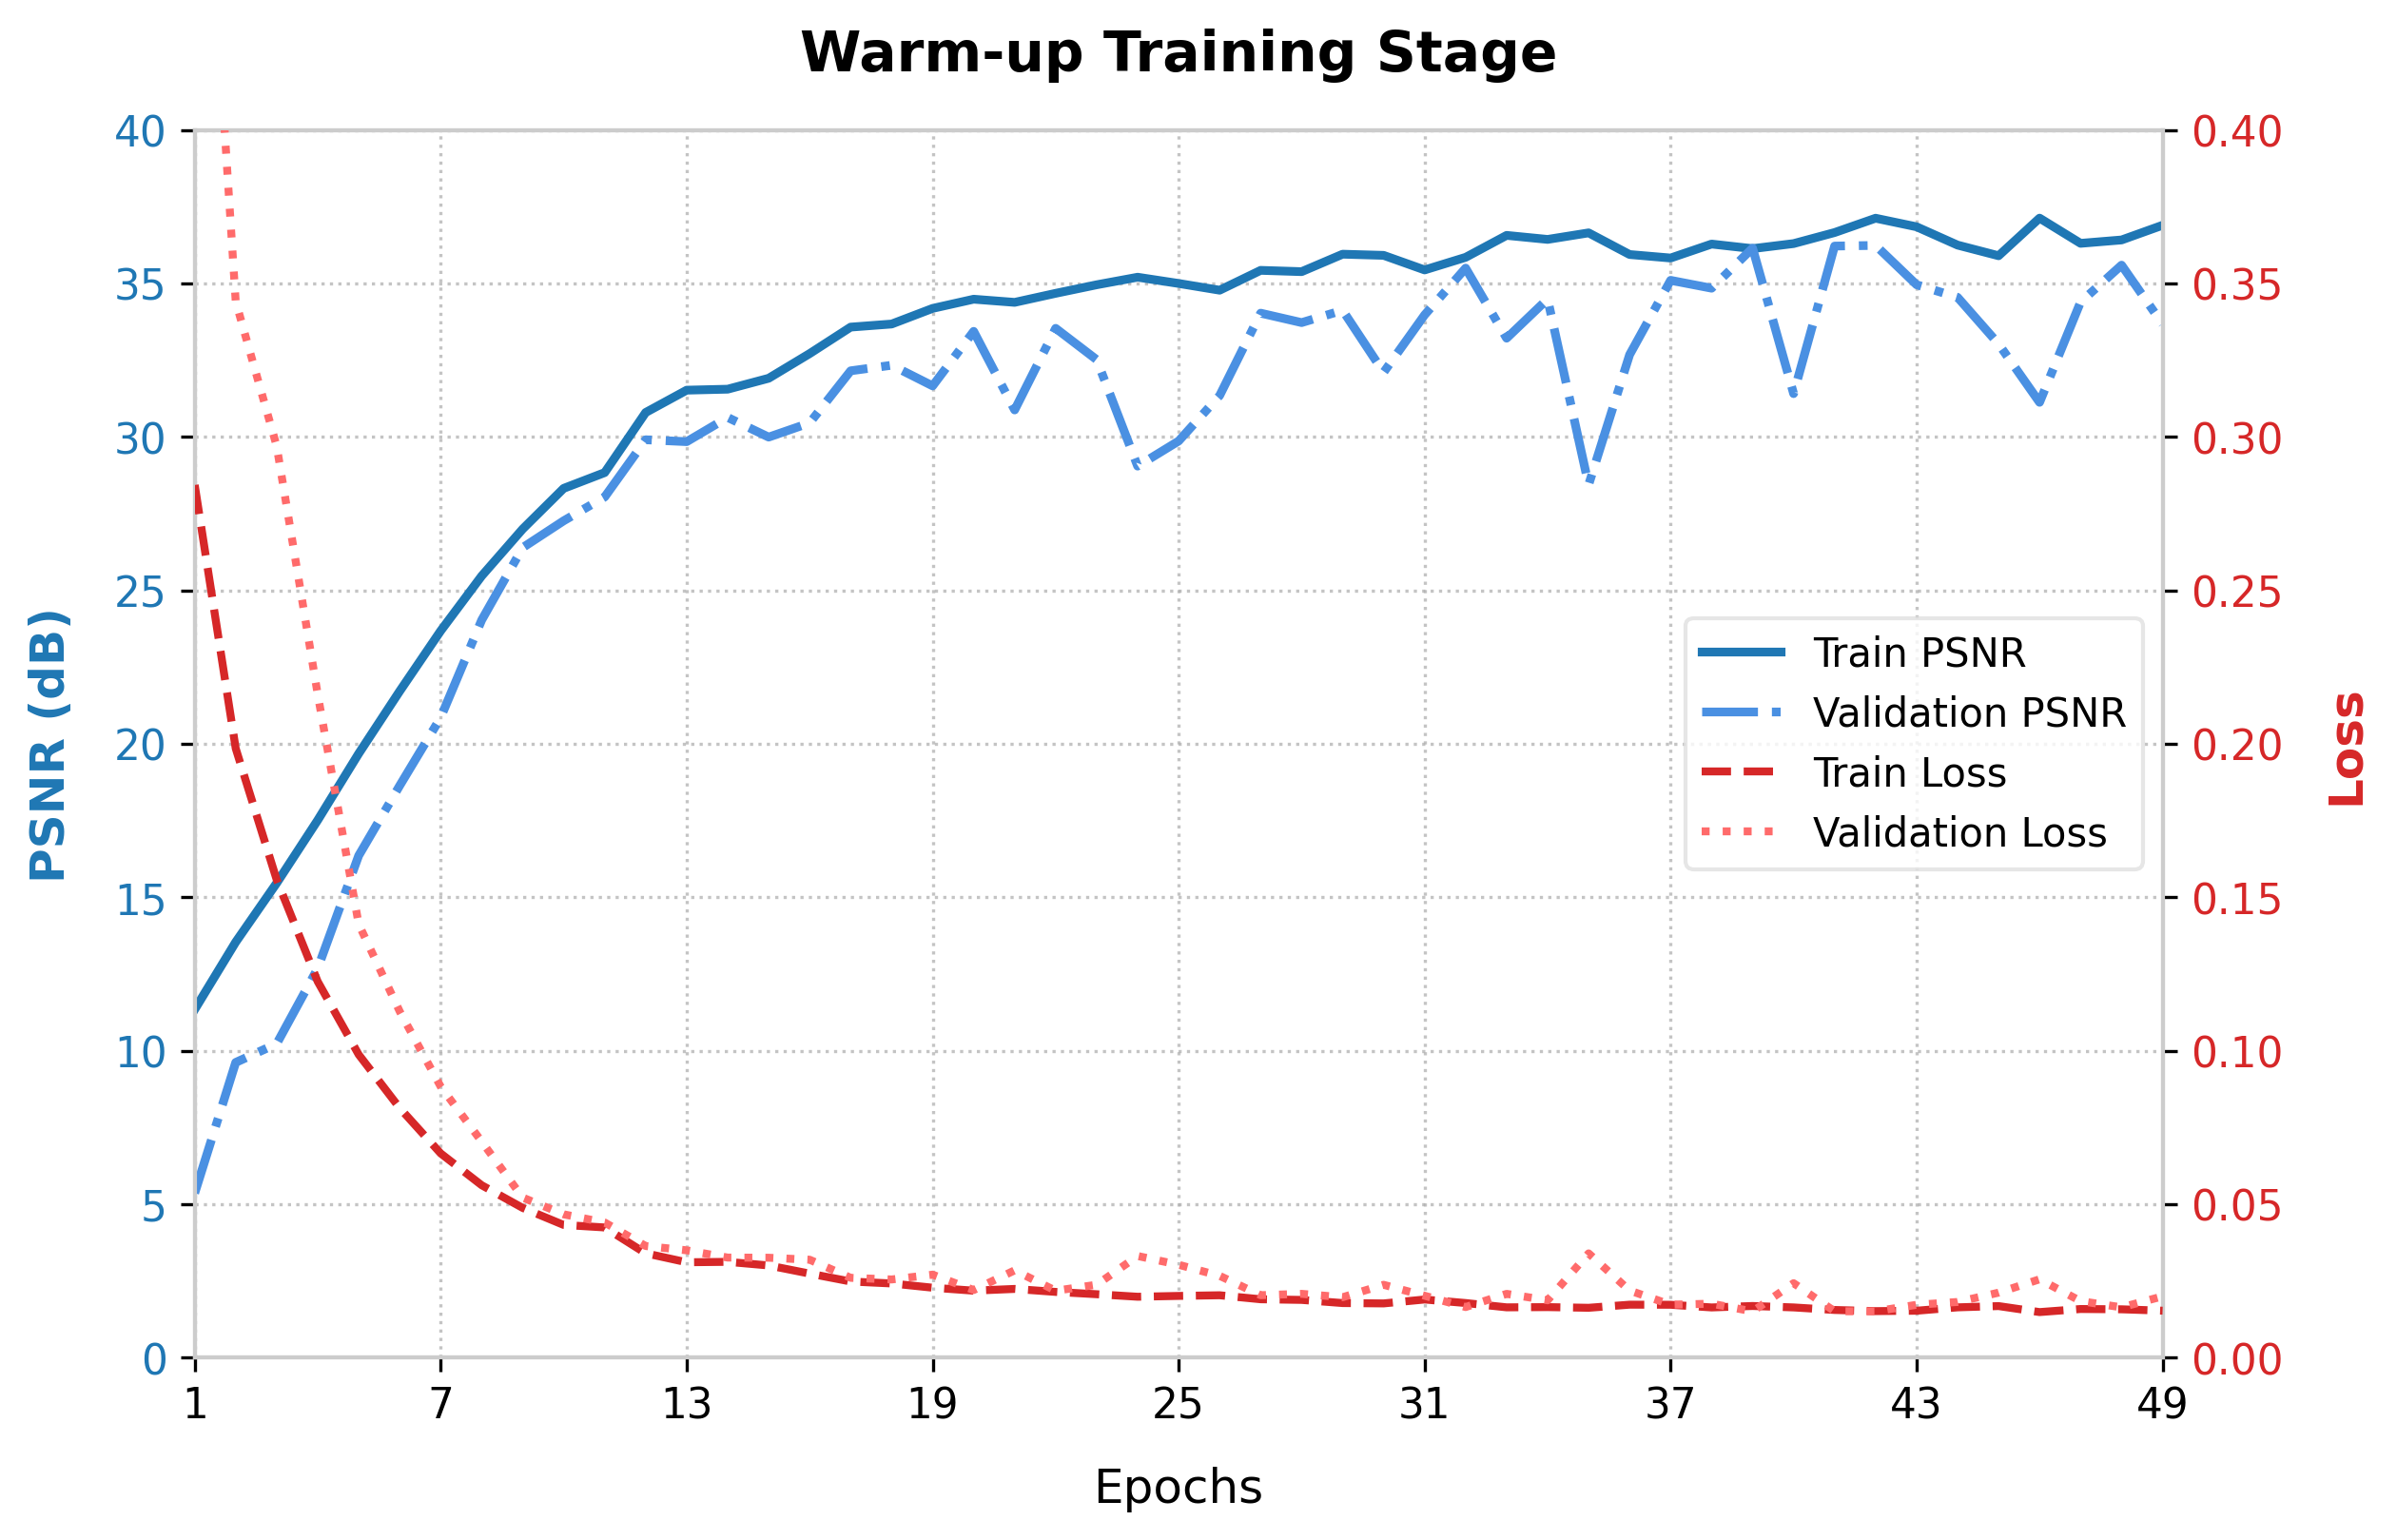

/kaggle/working/warm-up_training_stage_curve.png

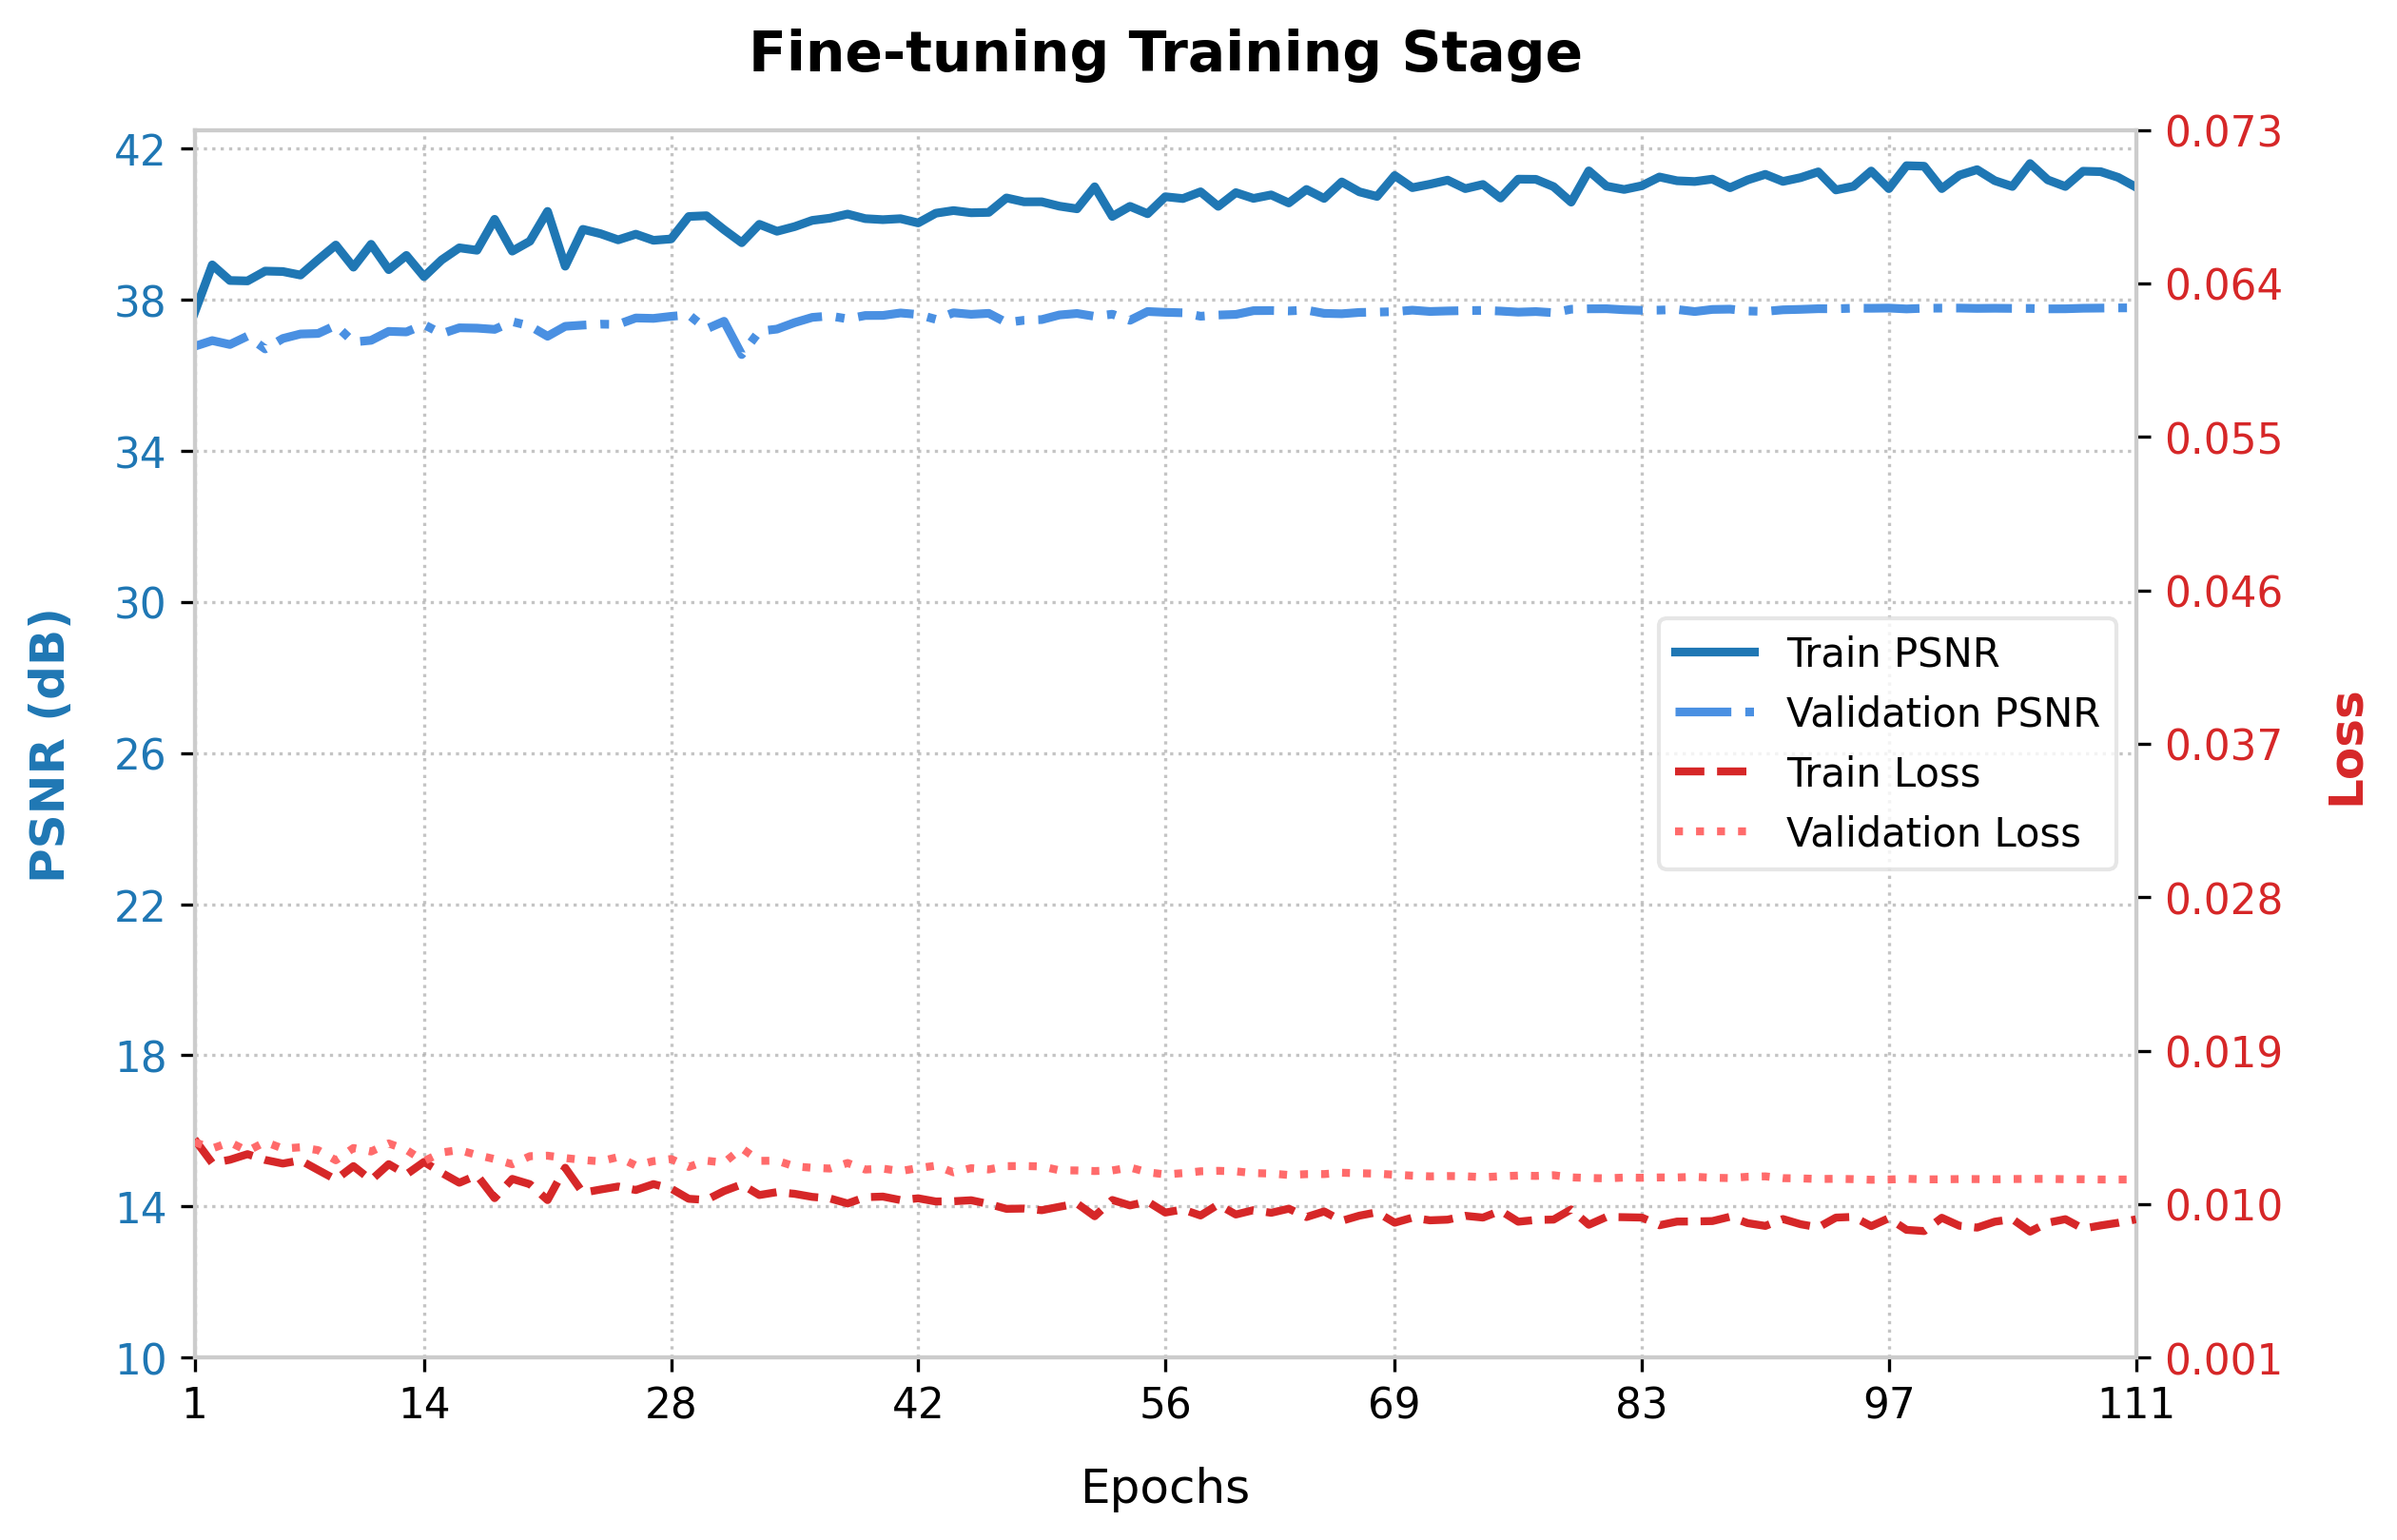

/kaggle/working/fine-tuning_training_stage_curve.png

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import FileLink, display

def plot_training_metrics_optimized(history_obj, title_name):
    """
    Generates publication-quality dual-axis plots with specific color grading.
    Both Warm-up and Fine-tuning stages are locked into a symmetric 8x8 grid matrix
    (8 X-axis intervals by 8 Y-axis intervals) with crisp integer labels for Epochs.
    """

    h = history_obj.history if hasattr(history_obj, 'history') else history_obj
    total_epochs = len(h['loss'])
    epochs = range(1, total_epochs + 1)

    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.edgecolor'] = '#CCCCCC'
    plt.rcParams['axes.linewidth'] = 1.0

    fig, ax1 = plt.subplots(figsize=(8.5, 5.5), dpi=300)

    # ---------------- Left Y-Axis: PSNR Values (BLUE Theme) ----------------
    line1 = ax1.plot(
        epochs, h['psnr'],
        color='#1F77B4', linestyle='-',
        linewidth=2.2, label='Train PSNR', zorder=3
    )

    line2 = ax1.plot(
        epochs, h['val_psnr'],
        color='#4A90E2', linestyle='-.',
        linewidth=2.2, label='Validation PSNR', zorder=3
    )

    ax1.set_xlabel('Epochs', fontsize=12, labelpad=10)
    ax1.set_ylabel(
        'PSNR (dB)',
        fontsize=12,
        labelpad=10,
        color='#1F77B4',
        fontweight='bold'
    )

    # X-axis
    ax1.set_xlim(1, total_epochs)

    x_ticks = np.linspace(1, total_epochs, 9).astype(int)
    x_ticks = np.unique(x_ticks)
    ax1.set_xticks(x_ticks)

    # ---------------- Left Axis (PSNR) ----------------
    if "Fine" in title_name:

        # Added only a little headroom so the curve doesn't touch the top
        ax1.set_ylim(10, 42.5)

        # Tick labels remain exactly like before
        ax1.set_yticks(np.linspace(10, 42, 9))

    else:

        ax1.set_ylim(0, 40)
        ax1.set_yticks(np.linspace(0, 40, 9))

    ax1.tick_params(axis='y', labelsize=10.5, labelcolor='#1F77B4')
    ax1.tick_params(axis='x', labelsize=10.5)

    # Grid
    ax1.grid(
        True,
        linestyle=':',
        alpha=0.75,
        color='#B0B0B0',
        linewidth=0.8,
        zorder=1
    )

    # ---------------- Right Y-Axis: Loss Values (RED Theme) ----------------
    ax2 = ax1.twinx()

    line3 = ax2.plot(
        epochs, h['loss'],
        color='#D62728',
        linestyle='--',
        linewidth=2.0,
        label='Train Loss',
        zorder=3
    )

    line4 = ax2.plot(
        epochs, h['val_loss'],
        color='#FF6B6B',
        linestyle=':',
        linewidth=2.0,
        label='Validation Loss',
        zorder=3
    )

    ax2.set_ylabel(
        'Loss',
        fontsize=12,
        labelpad=10,
        color='#D62728',
        fontweight='bold'
    )

    # ---------------- Right Axis (Loss) ----------------
    if "Fine" in title_name:

        # Lower limit reduced so the loss curve doesn't touch the bottom
        ax2.set_ylim(0.001, 0.073)

        # Keep 9 evenly spaced ticks
        ax2.set_yticks(np.linspace(0.001, 0.073, 9))

    else:

        ax2.set_ylim(0.0, 0.40)
        ax2.set_yticks(np.linspace(0.0, 0.40, 9))

    ax2.tick_params(axis='y', labelsize=10.5, labelcolor='#D62728')

    # ---------------- Legend ----------------
    all_lines = line1 + line2 + line3 + line4
    all_labels = [l.get_label() for l in all_lines]

    leg = ax1.legend(
        all_lines,
        all_labels,
        loc='center right',
        frameon=True,
        facecolor='white',
        edgecolor='#E0E0E0',
        fontsize=10
    )

    if leg:
        leg.set_zorder(4)

    plt.title(title_name, fontsize=14, fontweight='bold', pad=15)

    plt.tight_layout()

    save_filename = title_name.lower().replace(' ', '_') + '_curve.png'

    plt.savefig(save_filename, dpi=300, bbox_inches='tight')

    plt.show()

    return save_filename


# ---------------- Execution ----------------

fn_warmup = plot_training_metrics_optimized(
    history_warmup,
    'Warm-up Training Stage'
)
display(FileLink(fn_warmup))

fn_finetune = plot_training_metrics_optimized(
    history_finetune,
    'Fine-tuning Training Stage'
)
display(FileLink(fn_finetune))

In [20]:
# --- Rename and Save the Final Trained Model ---

# Update the model's internal name attribute for ResNet50V2 CT-MRI
fusion_model.name = "ResNet50V2_CT_MRI"

# Construct the dynamic file path using the updated name and the final Test PSNR score
model_save_path = f"/kaggle/working/{fusion_model.name}_(PSNR_{final_psnr:.2f}dB).keras"

print(f"Saving model to: {model_save_path}")
fusion_model.save(model_save_path)
print("Model saved successfully!")

Saving model to: /kaggle/working/ResNet50V2_CT_MRI_(PSNR_38.11dB).keras
Model saved successfully!
